In [1]:
import os
os.environ["PARCELS_COMPILER"] = "gcc"
os.environ["CC"] = "gcc"

# quick sanity check for kernel parcels
import sys
print("Python path:", sys.executable)
import parcels
print("Parcels version:", parcels.__version__)

Python path: C:\Users\woobs\miniconda3\python.exe
Parcels version: 3.1.4


In [2]:
import glob, numpy as np, xarray as xr, matplotlib.pyplot as plt
from datetime import timedelta
from parcels import (
    FieldSet, ParticleSet, ScipyParticle, JITParticle, AdvectionRK4,
    ParticleFile, Field, Variable, DiffusionUniformKh, GeographicPolar, Geographic
)
from netCDF4 import Dataset
import pandas as pd


In [ ]:
## USING 2009 ROMS SET
#
#   IMPORTANT: FILEPATH HERE. CHANGE TO MATCH INDIVIDUAL FILE PATHS
#
roms_path = r"C:\Users\woobs\OneDrive\Desktop\2009\*.nc" # to-do: try to make file paths dynamic to prevent having to change file paths every iteration(?)
roms_files = sorted(glob.glob(roms_path))
print("Found", len(roms_files), "files"); assert roms_files

def first_time_value(ncpath, time_name="time"):
    with xr.open_dataset(ncpath, decode_times=True) as ds:
        t = ds[time_name].values
        return np.atleast_1d(t)[0]

time_name = "time"
roms_files_sorted = [fp for fp,_ in sorted(
    [(fp, first_time_value(fp, time_name)) for fp in roms_files],
    key=lambda x: x[1]
)]


In [4]:

AGG_FACTOR = 5          # "convert resolution by factor of 5"
PR_THRESH  = 0.25       # below this -> 0 particles
WEIGHT_MULT = 10        # particles = round(PR * 10)


In [5]:
variables = {"U":"u","V":"v"}
dimensions = {
    "U":{"lon":"longitude","lat":"latitude","time":"time"},
    "V":{"lon":"longitude","lat":"latitude","time":"time"},
}
grid_file = roms_files_sorted[0]
filenames = {
    "U":{"lon":grid_file,"lat":grid_file,"data":roms_files_sorted,"time":roms_files_sorted},
    "V":{"lon":grid_file,"lat":grid_file,"data":roms_files_sorted,"time":roms_files_sorted},
}
indices = {"depth":[0]}
fieldset = FieldSet.from_netcdf(filenames, variables, dimensions,
                                mesh="spherical", allow_time_extrapolation=False,
                                indices=indices)
print("FieldSet OK (fresh)")


FieldSet OK (fresh)


In [6]:
# Quick domain bounds 
import numpy as np
LON_MIN, LON_MAX = float(np.min(fieldset.U.grid.lon)), float(np.max(fieldset.U.grid.lon))
LAT_MIN, LAT_MAX = float(np.min(fieldset.U.grid.lat)), float(np.max(fieldset.U.grid.lat))
print("Domain lon:", LON_MIN, "→", LON_MAX, " | lat:", LAT_MIN, "→", LAT_MAX)

# Detect available depth levels 
zlevels = np.asarray(fieldset.U.depth if hasattr(fieldset.U, "depth") else fieldset.U.grid.depth, dtype=float)
zlevels_sorted = np.sort(zlevels)
print("Depth levels:", zlevels_sorted)
TOP_LEVEL = float(zlevels_sorted[0]) 


Domain lon: -163.83070373535156 → -152.51930236816406  | lat: 17.0184326171875 → 23.982389450073242
Depth levels: [0.]


In [7]:
fieldset = FieldSet.from_netcdf(filenames, variables, dimensions,interp_method={'U': 'freeslip', 'V': 'freeslip'})

# In[12]:
#
#   IMPORTANT: FILEPATH HERE. CHANGE TO MATCH INDIVIDUAL FILE PATHS
#
file_path_fine = r"C:\Users\woobs\OneDrive\Desktop\2009\yr_2009_01.nc"


def make_landmask(fielddata):
    """Returns landmask where land = 1 and ocean = 0
    fielddata is a netcdf file.
    """
    datafile = Dataset(fielddata)

    landmask = datafile.variables['u'][0, 0]
    landmask = np.ma.masked_invalid(landmask) #remove Nas? 
    landmask = landmask.mask.astype('int')

    return landmask

#


landmask_fine = make_landmask(file_path_fine)


# In[28]:
def get_coastal_nodes(landmask):
    """Function that detects the coastal nodes, i.e. the ocean nodes directly
    next to land. Computes the Laplacian of landmask.

    - landmask: the land mask built using `make_landmask`, where land cell = 1
                and ocean cell = 0.

    Output: 2D array array containing the coastal nodes, the coastal nodes are
            equal to one, and the rest is zero.
    """
    mask_lap = np.roll(landmask, -1, axis=0) + np.roll(landmask, 1, axis=0)
    mask_lap += np.roll(landmask, -1, axis=1) + np.roll(landmask, 1, axis=1)
    mask_lap -= 4*landmask
    coastal = np.ma.masked_array(landmask, mask_lap > 0)
    coastal = coastal.mask.astype('int')

    return coastal

def get_shore_nodes(landmask):
    """Function that detects the shore nodes, i.e. the land nodes directly
    next to the ocean. Computes the Laplacian of landmask.

    - landmask: the land mask built using `make_landmask`, where land cell = 1
                and ocean cell = 0.

    Output: 2D array array containing the shore nodes, the shore nodes are
            equal to one, and the rest is zero.
    """
    mask_lap = np.roll(landmask, -1, axis=0) + np.roll(landmask, 1, axis=0)
    mask_lap += np.roll(landmask, -1, axis=1) + np.roll(landmask, 1, axis=1)
    mask_lap -= 4*landmask
    shore = np.ma.masked_array(landmask, mask_lap < 0)
    shore = shore.mask.astype('int')

    return shore

# In[13]:

def get_coastal_nodes_diagonal(landmask):
    """Function that detects the coastal nodes, i.e. the ocean nodes where 
    one of the 8 nearest nodes is land. Computes the Laplacian of landmask
    and the Laplacian of the 45 degree rotated landmask.

    - landmask: the land mask built using `make_landmask`, where land cell = 1
                and ocean cell = 0.

    Output: 2D array array containing the coastal nodes, the coastal nodes are
            equal to one, and the rest is zero.
    """
    mask_lap = np.roll(landmask, -1, axis=0) + np.roll(landmask, 1, axis=0)
    mask_lap += np.roll(landmask, -1, axis=1) + np.roll(landmask, 1, axis=1)
    mask_lap += np.roll(landmask, (-1,1), axis=(0,1)) + np.roll(landmask, (1, 1), axis=(0,1))
    mask_lap += np.roll(landmask, (-1,-1), axis=(0,1)) + np.roll(landmask, (1, -1), axis=(0,1))
    mask_lap -= 8*landmask
    coastal = np.ma.masked_array(landmask, mask_lap > 0)
    coastal = coastal.mask.astype('int')
    
    return coastal
    
def get_shore_nodes_diagonal(landmask):
    """Function that detects the shore nodes, i.e. the land nodes where 
    one of the 8 nearest nodes is ocean. Computes the Laplacian of landmask 
    and the Laplacian of the 45 degree rotated landmask.

    - landmask: the land mask built using `make_landmask`, where land cell = 1
                and ocean cell = 0.

    Output: 2D array array containing the shore nodes, the shore nodes are
            equal to one, and the rest is zero.
    """
    mask_lap = np.roll(landmask, -1, axis=0) + np.roll(landmask, 1, axis=0)
    mask_lap += np.roll(landmask, -1, axis=1) + np.roll(landmask, 1, axis=1)
    mask_lap += np.roll(landmask, (-1,1), axis=(0,1)) + np.roll(landmask, (1, 1), axis=(0,1))
    mask_lap += np.roll(landmask, (-1,-1), axis=(0,1)) + np.roll(landmask, (1, -1), axis=(0,1))
    mask_lap -= 8*landmask
    shore = np.ma.masked_array(landmask, mask_lap < 0)
    shore = shore.mask.astype('int')

    return shore
#
coastal_fine = get_coastal_nodes_diagonal(landmask_fine)
shore_fine = get_shore_nodes_diagonal(landmask_fine)

#
def create_displacement_field(landmask, double_cell=False):
    """Function that creates a displacement field 1 m/s away from the shore.

    - landmask: the land mask dUilt using `make_landmask`.
    - double_cell: Boolean for determining if you want a double cell.
      Default set to False.

    Output: two 2D arrays, one for each camponent of the velocity.
    """
    shore = get_shore_nodes(landmask)
    shore_d = get_shore_nodes_diagonal(landmask) # bordering ocean directly and diagonally
    shore_c = shore_d - shore                    # corner nodes that only border ocean diagonally
    
    Ly = np.roll(landmask, -1, axis=0) - np.roll(landmask, 1, axis=0) # Simple derivative
    Lx = np.roll(landmask, -1, axis=1) - np.roll(landmask, 1, axis=1)
    
    Ly_c = np.roll(landmask, -1, axis=0) - np.roll(landmask, 1, axis=0)
    Ly_c += np.roll(landmask, (-1,-1), axis=(0,1)) + np.roll(landmask, (-1,1), axis=(0,1)) # Include y-component of diagonal neighbours
    Ly_c += - np.roll(landmask, (1,-1), axis=(0,1)) - np.roll(landmask, (1,1), axis=(0,1))
    
    Lx_c = np.roll(landmask, -1, axis=1) - np.roll(landmask, 1, axis=1)
    Lx_c += np.roll(landmask, (-1,-1), axis=(1,0)) + np.roll(landmask, (-1,1), axis=(1,0)) # Include x-component of diagonal neighbours
    Lx_c += - np.roll(landmask, (1,-1), axis=(1,0)) - np.roll(landmask, (1,1), axis=(1,0))
    
    v_x = -Lx*(shore)
    v_y = -Ly*(shore)
    
    v_x_c = -Lx_c*(shore_c)
    v_y_c = -Ly_c*(shore_c)
    
    v_x = v_x + v_x_c
    v_y = v_y + v_y_c

    magnitude = np.sqrt(v_y**2 + v_x**2)
    # the coastal nodes between land create a problem. Magnitude there is zero
    # I force it to be 1 to avoid problems when normalizing.
    ny, nx = np.where(magnitude == 0)
    magnitude[ny, nx] = 1

    v_x = v_x/magnitude
    v_y = v_y/magnitude

    return v_x, v_y



##
v_x_f, v_y_f = create_displacement_field(landmask_fine)
#

def distance_to_shore(landmask, dx=1):
    """Function that computes the distance to the shore. It is based in the
    the `get_coastal_nodes` algorithm.

    - landmask: the land mask dUilt using `make_landmask` function.
    - dx: the grid cell dimension. This is a crude approxsimation of the real
    distance (be careful).

    Output: 2D array containing the distances from shore.
    """
    ci = get_coastal_nodes(landmask) # direct neighbours
    dist = ci*dx                     # 1 dx away
    
    ci_d = get_coastal_nodes_diagonal(landmask) # diagonal neighbours
    dist_d = (ci_d - ci)*np.sqrt(2*dx**2)       # sqrt(2) dx away
        
    return dist+dist_d

#
d_2_s_f = distance_to_shore(landmask_fine)

#
def set_displacement(particle, fieldset, time):
    """Clamp to safe inner bounds before sampling static fields."""
    # use SAFE_* + EPS to stay one full cell in
    if particle.lon <= fieldset.SAFE_LON_MIN:
        particle.lon = fieldset.SAFE_LON_MIN + fieldset.LON_EPS
    if particle.lon >= fieldset.SAFE_LON_MAX:
        particle.lon = fieldset.SAFE_LON_MAX - fieldset.LON_EPS
    if particle.lat <= fieldset.SAFE_LAT_MIN:
        particle.lat = fieldset.SAFE_LAT_MIN + fieldset.LAT_EPS
    if particle.lat >= fieldset.SAFE_LAT_MAX:
        particle.lat = fieldset.SAFE_LAT_MAX - fieldset.LAT_EPS

    particle.d2s = fieldset.distance2shore_fine[time, particle.depth, particle.lat, particle.lon]

    if particle.d2s < fieldset.shore_threshold:
        particle.dU = fieldset.dispUF[time, particle.depth, particle.lat, particle.lon]
        particle.dV = fieldset.dispVF[time, particle.depth, particle.lat, particle.lon]
    else:
        particle.dU = 0.0
        particle.dV = 0.0



##
def displace(particle, fieldset, time):    
    if  particle.d2s < 0.5:
        particle.lon += particle.dU*particle.dt
        particle.lat += particle.dV*particle.dt
##
u_displacement_f = v_x_f
v_displacement_f = v_y_f
#
fieldset.add_field(Field('dispUF', data=u_displacement_f,
                         lon=fieldset.U.grid.lon, lat=fieldset.U.grid.lat,
                         mesh='spherical')) #have to index to choose which field we want to base it off of; 1 is choosing coarser

fieldset.add_field(Field('dispVF', data=v_displacement_f,
                         lon=fieldset.U.grid.lon, lat=fieldset.U.grid.lat,
                         mesh='spherical'))
fieldset.dispUF.units = GeographicPolar()
fieldset.dispVF.units = Geographic()
fieldset.add_field(Field('landmask_fine', landmask_fine,
                         lon=fieldset.U.grid.lon, lat=fieldset.U.grid.lat,
                         mesh='spherical'))
fieldset.add_field(Field('distance2shore_fine', d_2_s_f,
                         lon=fieldset.U.grid.lon, lat=fieldset.U.grid.lat,
                         mesh='spherical'))
class DisplacementParticle(JITParticle):
    dU = Variable('dU')
    dV = Variable('dV')
    d2s = Variable('d2s', initial=1e3)
    age = Variable('age', dtype=np.float32, initial=0.)
    cycle_phase=Variable('cycle_phase', dtype=np.float32, initial=0.)
    releaseSite = Variable('releaseSite', dtype=np.int32)
    distance = Variable('distance', dtype=np.int32, initial=0.) # not calculating distance for now but left this in
    prev_lat = Variable('prev_lat', initial=0., to_write=False)  
    prev_lon = Variable('prev_lon', initial=0., to_write=False)
    f = Variable('f', dtype=np.int32)

In [8]:
# ============================================================
# DisplacementParticle Settlement variables
# ============================================================

import numpy as np
from parcels import JITParticle, Variable

class DisplacementParticle(JITParticle):
    dU = Variable('dU')
    dV = Variable('dV')
    d2s = Variable('d2s', initial=1e3)

    # existing
    age = Variable('age', dtype=np.float32, initial=0.)
    cycle_phase = Variable('cycle_phase', dtype=np.float32, initial=0.)
    releaseSite = Variable('releaseSite', dtype=np.int32)
    distance = Variable('distance', dtype=np.int32, initial=0.)
    prev_lat = Variable('prev_lat', initial=0., to_write=False)
    prev_lon = Variable('prev_lon', initial=0., to_write=False)
    f = Variable('f', dtype=np.int32)

    # ------------------------------------------------------------
    # Settlement tracking (NEW)
    # ------------------------------------------------------------
    settled = Variable('settled', dtype=np.int32, initial=0)
    settle_time = Variable('settle_time', dtype=np.float32, initial=-1.0)
    settle_lon  = Variable('settle_lon', dtype=np.float32, initial=np.nan)
    settle_lat  = Variable('settle_lat', dtype=np.float32, initial=np.nan)

In [9]:
# === Delete particles that hit land (using fieldset.landmask_fine) ===

def KillIfOnLand(particle, fieldset, time):
    # landmask_fine: land=1, ocean=0
    lm = fieldset.landmask_fine[time, particle.depth, particle.lat, particle.lon]
    if lm >= 0.5:
        particle.delete()


In [10]:
# --- depth info from ROMS and safe constants ---

# Get all the depth levels that the ocean model uses.
# Think of this as a list of water depths where the model can place particles.
zlevels = np.asarray(getattr(fieldset.U, "depth", fieldset.U.grid.depth), dtype=float)

# Sort those depth values from shallowest to deepest.
# This makes it easy to grab the top (shallowest) and bottom (deepest) depths.
zlevels_sorted = np.sort(zlevels)

# Save the shallowest depth from the model.
# We use this so we know how close to the "surface" we’re allowed to start.
DEPTH_MIN = float(zlevels_sorted[0])  # e.g., 60.0

# Save the deepest depth from the model.
# This tells us how far down the model goes, so we don’t try to go past it.
DEPTH_MAX = float(zlevels_sorted[-1])  # e.g., 100.0

# Pick the shallowest depth as the depth where things will drift.
# This is used to put eggs/particles as close to the surface as the model allows.
DRIFT_DEPTH = DEPTH_MIN

# Store these values inside the fieldset so all parts of the code can use them.
# This keeps everything consistent and avoids hard-coding numbers in many places.
fieldset.add_constant("DEPTH_MIN",   DEPTH_MIN)
fieldset.add_constant("DEPTH_MAX",   DEPTH_MAX)
fieldset.add_constant("DRIFT_DEPTH", DRIFT_DEPTH)

# Use the drift depth as the "top level" for particles.
# This means eggs start at a depth that is valid for the model instead of an
# unrealistic depth that could crash the run.
TOP_LEVEL = DRIFT_DEPTH
fieldset.add_constant("TOP_LEVEL", TOP_LEVEL)


In [11]:
# --- Edge nudges so particles don't sit exactly on the boundary ---
import numpy as np

# Grab all the longitude (left–right) positions from the model grid
LON_arr = np.asarray(fieldset.U.grid.lon, dtype=float)

# Grab all the latitude (up–down) positions from the model grid
LAT_arr = np.asarray(fieldset.U.grid.lat, dtype=float)

# Estimate a "typical" spacing between longitudes.
# tells us roughly how far apart the grid points are left–to–right.
LON_DX = float(np.nanmedian(np.abs(np.diff(LON_arr))))

# Estimate a "typical" spacing between latitudes.
# tells us roughly how far apart the grid points are up–down.
LAT_DY = float(np.nanmedian(np.abs(np.diff(LAT_arr))))

# Store a small nudge distance in longitude (1/4 of a grid step).
# push particles slightly away from the very edge, so they don't sit exactly on the border and cause "out of bounds" problems.
fieldset.add_constant("LON_EPS", 0.25 * LON_DX)

# Store a small nudge distance in latitude (1/4 of a grid step).
# gently move particles away from the top/bottom borders
fieldset.add_constant("LAT_EPS", 0.25 * LAT_DY)

# Find the shallowest depth level in the model.
# We save this so we know the highest (closest to surface) depth we can use.
fieldset.add_constant(
    "DEPTH_MIN",
    float(np.min(getattr(fieldset.U, "depth", fieldset.U.grid.depth)))
)

# Find the deepest depth level in the model.
# save this so we know the lowest depth we can go to without breaking the model.
fieldset.add_constant(
    "DEPTH_MAX",
    float(np.max(getattr(fieldset.U, "depth", fieldset.U.grid.depth)))
)


In [12]:
# --- Make a clean list of Opakapaka release locations that are only in the ocean ---

import numpy as np, pandas as pd, xarray as xr

# A) Load the habitat CSV file
# This file lists possible release spots for Opakapaka, with their longitude, latitude, and weights.
#
#   IMPORTANT: FILEPATH HERE. CHANGE TO MATCH INDIVIDUAL FILE PATHS
#
release_csv = r"C:\Users\woobs\OneDrive\Desktop\Opakapaka_General_Habitat_PB.csv"
df = pd.read_csv(release_csv, header=None, names=["id", "lon", "lat", "weight"])

# Turn the longitude and latitude columns into regular arrays so we can work with them easily.
release_lons_raw = df["lon"].to_numpy(dtype=float)
release_lats_raw = df["lat"].to_numpy(dtype=float)

# Print how many total points we started with.
print(f"Loaded {release_lons_raw.size:,} candidate release points from CSV")

# B) Remove any points that fall outside the ocean model area (the ROMS grid)
# This makes sure we only keep points inside the part of the ocean your model covers.
LON_MIN, LON_MAX = float(np.min(fieldset.U.grid.lon)), float(np.max(fieldset.U.grid.lon))
LAT_MIN, LAT_MAX = float(np.min(fieldset.U.grid.lat)), float(np.max(fieldset.U.grid.lat))

# Check which points fall inside the model’s box.
in_box = (
    (release_lons_raw >= LON_MIN) & (release_lons_raw <= LON_MAX) &
    (release_lats_raw >= LAT_MIN) & (release_lats_raw <= LAT_MAX)
)

# Keep only those that are inside.
release_lons_box = release_lons_raw[in_box]
release_lats_box = release_lats_raw[in_box]
print(f"After domain box filter: {release_lons_box.size:,} points")

# C) Use the model data to tell which points are on land and which are in the ocean.
# The ROMS file stores ocean current data. If a point’s value is NaN (not a number),
# that means it’s on land, so we skip those.
roms_first = roms_files_sorted[0]
with xr.open_dataset(roms_first, decode_times=True) as ds:
    # Take a single time and depth layer from the U (east-west current) data.
    u0 = ds["u"].isel(time=0, depth=0).load()

    # Find the value closest to each release point.
    sampled = u0.interp(
        longitude=("points", release_lons_box),
        latitude=("points", release_lats_box),
        method="nearest"
    ).values

# Keep only the points where the data exists (those are the ocean points).
keep_ocean = np.isfinite(sampled)
release_lons = release_lons_box[keep_ocean]
release_lats = release_lats_box[keep_ocean]

# Print how many valid ocean release points are left.
print(f"After ocean mask: {release_lons.size:,} points kept (ocean only)")


Loaded 2,122,319 candidate release points from CSV
After domain box filter: 2,122,319 points
After ocean mask: 2,063,024 points kept (ocean only)


In [13]:
zlevels = np.asarray(getattr(fieldset.U, "depth", fieldset.U.grid.depth), dtype=float)
zlevels_sorted = np.sort(zlevels)
fieldset.add_constant('DEPTH_MIN', float(zlevels_sorted[0]))
fieldset.add_constant('DEPTH_MAX', float(zlevels_sorted[-1]))
fieldset.add_constant('TOP_LEVEL', float(zlevels_sorted[0]))


In [14]:
fieldset.add_constant('TOP_LEVEL', float(TOP_LEVEL))


In [15]:
#
#   IMPORTANT: FILEPATH HERE. CHANGE TO MATCH INDIVIDUAL FILE PATHS
#
release_csv = r"C:\Users\woobs\OneDrive\Desktop\Opakapaka_General_Habitat_PB.csv"
release_df = pd.read_csv(release_csv, header=None, names=["id","lon","lat","weight"])
print("Total sites:", len(release_df))


Total sites: 2122319


In [ ]:
import numpy as np
import pandas as pd

#
#   IMPORTANT: FILEPATH HERE. CHANGE TO MATCH INDIVIDUAL FILE PATHS
#
release_csv = r"C:\Users\woobs\OneDrive\Desktop\Opakapaka_General_Habitat_PB.csv"

# 1) Load the CSV
df = pd.read_csv(release_csv, header=None,
                 names=["id", "lon", "lat", "weight"])

# 2) Keep only places above threshold
df = df[df["weight"] > PR_THRESH].copy()
print("After threshold:", len(df), "points")

# 3) Group into bigger bins (~250m-ish)
BIN_DEG = 0.002

df["lon_bin"] = (df["lon"] / BIN_DEG).round().astype(int)
df["lat_bin"] = (df["lat"] / BIN_DEG).round().astype(int)

# 4) Aggregate bins into one release site
agg = df.groupby(["lon_bin", "lat_bin"], as_index=False).agg(
    lon=("lon", "mean"),
    lat=("lat", "mean"),
    weight=("weight", "mean")
)

print("After aggregation:", len(agg), "release cells")

# 5) Convert weight -> particle counts
agg["n_particles"] = (agg["weight"] * WEIGHT_MULT).round().astype(int)
agg = agg[agg["n_particles"] > 0].copy()

print("Final release sites:", len(agg))
print("Total particles:", int(agg["n_particles"].sum()))

# 6) Release arrays
release_lons = agg["lon"].to_numpy(float)
release_lats = agg["lat"].to_numpy(float)
release_counts = agg["n_particles"].to_numpy(int)


In [17]:

lon = np.repeat(release_lons, release_counts)
lat = np.repeat(release_lats, release_counts)

print("Spawn points created:", lon.size)


Spawn points created: 103729


In [18]:
print("release sites:", len(release_lons))
print("total particles:", int(release_counts.sum()))
print("spawn points created:", lon.size)
print("min/max weight:", float(agg["weight"].min()), float(agg["weight"].max()))
print("min/max n_particles:", int(agg["n_particles"].min()), int(agg["n_particles"].max()))


release sites: 28431
total particles: 103729
spawn points created: 103729
min/max weight: 0.250000536441803 0.7609866708517075
min/max n_particles: 3 8


In [31]:
# --- Set up constants and settings for the model  ---
import numpy as np

# 0) Make sure we have release points ready
# This checks if the variables holding your release locations exist.
# If they don’t, it gives an error reminding you to run the earlier setup cell.
if 'release_lons' in globals() and 'release_lats' in globals():
    lon = np.asarray(release_lons, dtype=float)
    lat = np.asarray(release_lats, dtype=float)
elif 'lon' in globals() and 'lat' in globals():
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
else:
    raise NameError("No release positions found. Run the habitat/ocean-mask selection cell first.")

# 1) Get the domain limits (edges) of the model
# These values mark the minimum and maximum longitudes and latitudes
# in the ROMS grid — basically, the edges of your ocean model area.
LON_MIN, LON_MAX = float(np.min(fieldset.U.grid.lon)), float(np.max(fieldset.U.grid.lon))
LAT_MIN, LAT_MAX = float(np.min(fieldset.U.grid.lat)), float(np.max(fieldset.U.grid.lat))

# 2) Make these limits available to the particles
# This allows your particles to “see” the boundaries
# so kernels can keep them inside the domain if needed.
fieldset.add_constant('LON_MIN', LON_MIN)
fieldset.add_constant('LON_MAX', LON_MAX)
fieldset.add_constant('LAT_MIN', LAT_MIN)
fieldset.add_constant('LAT_MAX', LAT_MAX)

# 3) Define a shoreline buffer distance
# This sets how close a particle can get to the coast before being considered “too close.”
# The number 5.0 here means 5 grid cells from shore 
fieldset.add_constant('shore_threshold', 5.0)

# 4) Pick the top layer of the model for particle release depth
# The ROMS data includes multiple depths (e.g., 0m, 10m, 20m, etc.).
# This finds the shallowest one — where your Opakapaka eggs or larvae start.
try:
    TOP_LEVEL = float(zlevels_sorted[0])  # use the first (top) depth level if already sorted
except NameError:
    # if not yet defined, get the depth levels directly from the model and sort them
    zlevels = np.asarray(getattr(fieldset.U, "depth", fieldset.U.grid.depth), dtype=float)
    zlevels_sorted = np.sort(zlevels)
    TOP_LEVEL = float(zlevels_sorted[0])

# Print a short summary so you can confirm everything looks right
print(f"Release count: {lon.size} | TOP_LEVEL={TOP_LEVEL} m")
print(f"Domain lon:[{LON_MIN:.2f},{LON_MAX:.2f}] lat:[{LAT_MIN:.2f},{LAT_MAX:.2f}]")


Release count: 28431 | TOP_LEVEL=0.0 m
Domain lon:[-163.83,-152.52] lat:[17.02,23.98]


In [34]:
# LOADING IN BATHYMETRY DATA #

# --- geotiff overlay (etopo) : load + helper sampler ---

# path to the bathymetry GeoTIFF (ETOPO 2022 bedrock, 15 arcseconds)
#
#   IMPORTANT: FILEPATH HERE. CHANGE TO MATCH INDIVIDUAL FILE PATHS
#
tif_path = r"C:\Users\woobs\OneDrive\Documents\Academics\Spring2026\OPAK\ETOPO_2022 (Bedrock; 15 arcseconds).tiff"

import os
import numpy as np

# rasterio is the standard library for reading GeoTIFFs + handling CRS/transform metadata
import rasterio
from rasterio.warp import transform as rio_transform

# 1) confirm file exists before trying to open it (prevents a cryptic rasterio error later)
if not os.path.exists(tif_path):
    raise FileNotFoundError(
        f"GeoTIFF not found at:\n{tif_path}\n\nCheck spelling + extension (.tif/.tiff)."
    )

# 2) open the raster and read band 1
# src holds the raster plus spatial metadata (crs, bounds, resolution, etc.)
src = rasterio.open(tif_path)

# grab raster metadata for sanity checks + plotting extents
tif_crs = src.crs          # coordinate reference system (we want EPSG:4326 to match lon/lat points)
tif_bounds = src.bounds    # bounding box in raster coordinate units (lon/lat if EPSG:4326)
tif_nodata = src.nodata    # value used for missing data (can be None)

print("GeoTIFF loaded")
print("  CRS:", tif_crs)
print("  Bounds:", tif_bounds)
print("  Nodata:", tif_nodata)
print("  Shape (h, w):", (src.height, src.width))  # raster dimensions in pixels
print("  Pixel size:", src.res)                     # raster resolution in coordinate units (degrees if EPSG:4326)

# read the raster values (band 1). for ETOPO, values are typically meters:
#   positive = above sea level (land)
#   negative = below sea level (ocean depth)
tif_data = src.read(1)  # band 1

# optional: mask nodata values so plots/statistics don't get polluted
# (turns nodata cells into NaN)
if tif_nodata is not None:
    tif_data = np.where(tif_data == tif_nodata, np.nan, tif_data)

# 3) sampler: get raster values at lon/lat points
# this lets us "attach" bathymetry values to release points or particle locations
def sample_tif_at_lonlat(lons, lats):
    """
    lons, lats: arrays (same shape) in degrees (WGS84 lon/lat)
    returns: array of sampled tif values with same shape
    """
    lons = np.asarray(lons)
    lats = np.asarray(lats)

    # flatten arrays so we can feed coordinates to rasterio.sample()
    lon_flat = lons.ravel()
    lat_flat = lats.ravel()

    # if raster CRS isn't EPSG:4326 reproject points into raster CRS before sampling. sanity check
    # if later switch to a projected GeoTIFF
    if tif_crs is not None and tif_crs.to_string() not in ("EPSG:4326", "OGC:CRS84"):
        xs, ys = rio_transform("EPSG:4326", tif_crs, lon_flat.tolist(), lat_flat.tolist())
        coords = list(zip(xs, ys))
    else:
        # most common case: raster already in lon/lat degrees
        coords = list(zip(lon_flat.tolist(), lat_flat.tolist()))

    # rasterio.sample returns one value per coordinate; v[0] grabs band 1
    vals = np.array([v[0] for v in src.sample(coords)], dtype=float)

    # replace nodata samples with NaN if nodata exists
    if tif_nodata is not None:
        vals = np.where(vals == tif_nodata, np.nan, vals)

    # reshape back to the original shape of (lons, lats)
    return vals.reshape(lons.shape)

# 4) quick sanity: sample at releases (if these exist in the notebook at this point)
# this creates release_etopo, which is bathymetry value at each release location
if "release_lons" in globals() and "release_lats" in globals():
    release_etopo = sample_tif_at_lonlat(release_lons, release_lats)
    print("Sampled ETOPO at release points (release_etopo created)")
else:
    print("Note: release_lons/release_lats not found yet in this notebook scope.")

GeoTIFF loaded
  CRS: EPSG:4326
  Bounds: BoundingBox(left=-163.0, bottom=17.0, right=-153.0, top=23.0)
  Nodata: None
  Shape (h, w): (1440, 2400)
  Pixel size: (0.004166666666666667, 0.004166666666666667)
Sampled ETOPO at release points (release_etopo created)


In [35]:
# ============================================================
# SETTLEMENT CONDITIONS (CAN CHANGE)
# Build potential settlement habitat = 40–60 m depth band,
# then buffer that habitat outward by 4 km,
# then rasterize onto ROMS grid -> fieldset.settle_mask
# ============================================================

import numpy as np

# --- Settlement timing (PLD window) --- <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< CHANGE WHEN PLD IS DECIDED
PLD_MIN_DAYS = 30
PLD_MAX_DAYS = 80

# --- Habitat definition (depth band) ---
# 40–60 m underwater means depths between -40 and -60
MIN_DEPTH = -60   # deeper
MAX_DEPTH = -40   # shallower

# --- Buffer around habitat (meters) ---
BUFFER_M = 4000   # 4 km

# Store PLD constants on fieldset so kernels can read them
fieldset.add_constant("PLD_MIN_SEC", float(PLD_MIN_DAYS) * 86400.0)
fieldset.add_constant("PLD_MAX_SEC", float(PLD_MAX_DAYS) * 86400.0)

print(f"PLD window set: {PLD_MIN_DAYS}–{PLD_MAX_DAYS} days")
print(f"Habitat band: {abs(MAX_DEPTH)}–{abs(MIN_DEPTH)} m | Buffer: {BUFFER_M} m")

# ============================================================
# 1) Build habitat polygons from GeoTIFF bathymetry (tif_data)
# ============================================================

try:
    import geopandas as gpd
    from shapely.geometry import shape
    from rasterio import features
except Exception as e:
    raise ImportError(
        "This cell requires geopandas + shapely + pyproj + rasterio.\n"
        "In conda, run:\n"
        "  conda install -c conda-forge geopandas shapely pyproj rasterio\n"
        "Then restart kernel and rerun."
    ) from e

# mask for 40–60 m band
depth_mask = np.logical_and(tif_data <= MAX_DEPTH, tif_data >= MIN_DEPTH)

shapes_gen = features.shapes(
    depth_mask.astype(np.uint8),
    mask=depth_mask,
    transform=src.transform
)

polygons = [shape(geom) for geom, value in shapes_gen if value == 1]
gdf_hab = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")

# ============================================================
# 2) Buffer habitat polygons by 4 km (project to meters first)
# ============================================================

gdf_hab_m = gdf_hab.to_crs("EPSG:3857")
gdf_hab_m["geometry"] = gdf_hab_m.buffer(BUFFER_M)

# dissolve into one habitat region
habitat_poly_m = gdf_hab_m.dissolve()
habitat_poly = habitat_poly_m.to_crs("EPSG:4326")

print("Buffered habitat polygon created.")

# ============================================================
# 3) Rasterize buffered habitat polygon onto ROMS grid -> settle_mask
# ============================================================

from affine import Affine
from parcels import Field

grid_lon = np.asarray(fieldset.U.grid.lon)
grid_lat = np.asarray(fieldset.U.grid.lat)

# derive 1D axes if grid is 2D regular
if grid_lon.ndim == 2 and grid_lat.ndim == 2:
    lon1d = grid_lon[0, :]
    lat1d = grid_lat[:, 0]
else:
    lon1d = grid_lon
    lat1d = grid_lat

nx = len(lon1d)
ny = len(lat1d)

xres = (float(np.max(lon1d)) - float(np.min(lon1d))) / (nx - 1)
yres = (float(np.max(lat1d)) - float(np.min(lat1d))) / (ny - 1)

transform = (
    Affine.translation(float(np.min(lon1d)) - xres/2, float(np.min(lat1d)) - yres/2)
    * Affine.scale(xres, yres)
)

shapes_to_raster = [(geom, 1) for geom in habitat_poly.geometry]

settle_mask = features.rasterize(
    shapes=shapes_to_raster,
    out_shape=(ny, nx),
    transform=transform,
    fill=0,
    dtype=np.float32
).astype(np.float32)

# overwrite if exists
try:
    fieldset.delete_field("settle_mask")
except Exception:
    pass

# If settle_mask already exists on the fieldset, remove it first
if hasattr(fieldset, "settle_mask"):
    delattr(fieldset, "settle_mask")

fieldset.add_field(Field(
    name="settle_mask",
    data=settle_mask,
    lon=lon1d,
    lat=lat1d,
    mesh="spherical"
))

print("fieldset.settle_mask created from buffered 40–60 m habitat band.")

PLD window set: 30–80 days
Habitat band: 40–60 m | Buffer: 4000 m
Buffered habitat polygon created.
fieldset.settle_mask created from buffered 40–60 m habitat band.


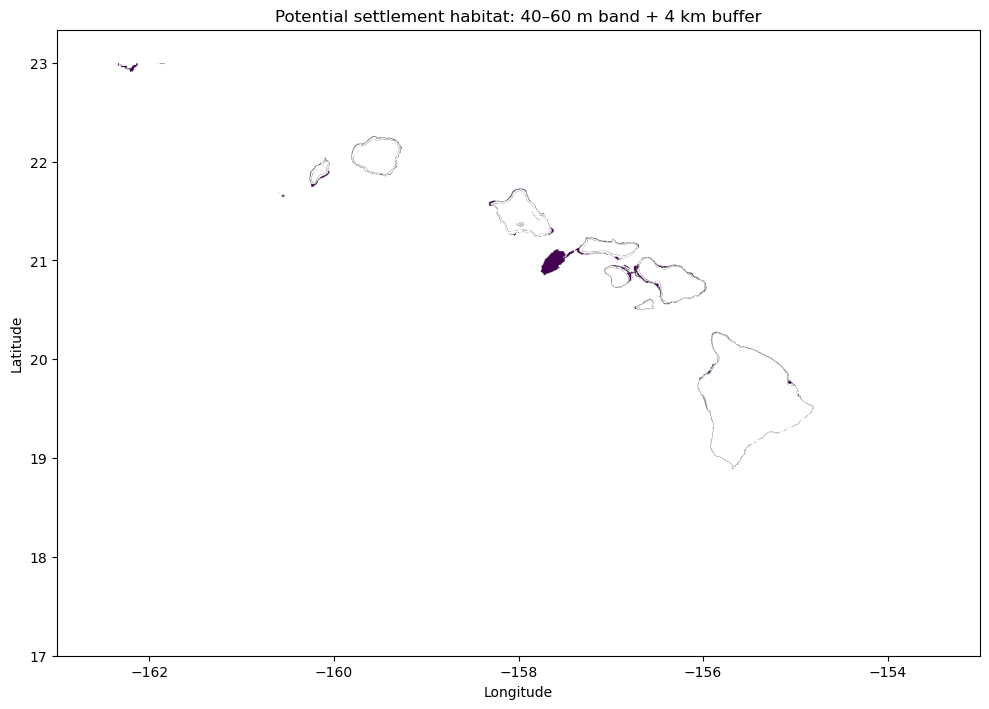

In [36]:
# # ============================================================
# # SANITY CHECK
# # View the 40–60 m depth band + buffered potential habitat outline
# # (keeps white islands)
# # ============================================================

# import numpy as np
# import matplotlib.pyplot as plt

# import geopandas as gpd
# from shapely.geometry import shape
# from rasterio import features

# BUFFER_M = 4000  # 4 km

# # 40–60 m band (ETOPO: negative depths underwater)
# MIN_DEPTH = -60   # deeper
# MAX_DEPTH = -40   # shallower

# # --- build the raw band mask for visualization ---
# band = np.where((tif_data >= MIN_DEPTH) & (tif_data <= MAX_DEPTH), 1.0, np.nan)

# extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# plt.figure(figsize=(10, 8))

# # show the band only (simple mask)
# plt.imshow(band, extent=extent, origin="upper", aspect="equal")

# # overlay land as white
# land_overlay = np.where(tif_data >= 0, 1, np.nan)
# plt.imshow(
#     land_overlay,
#     extent=extent,
#     origin="upper",
#     aspect="equal",
#     cmap="gray",
#     vmin=0,
#     vmax=1
# )

# # --- build buffered habitat polygon outline (same method as settlement mask prep) ---
# depth_mask = np.logical_and(tif_data <= MAX_DEPTH, tif_data >= MIN_DEPTH)

# shapes_gen = features.shapes(
#     depth_mask.astype(np.uint8),
#     mask=depth_mask,
#     transform=src.transform
# )

# polygons = [shape(geom) for geom, value in shapes_gen if value == 1]
# gdf_hab = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")

# gdf_hab_m = gdf_hab.to_crs("EPSG:3857")
# gdf_hab_m["geometry"] = gdf_hab_m.buffer(BUFFER_M)
# habitat_poly = gdf_hab_m.dissolve().to_crs("EPSG:4326")

# # plot the buffered outline
# ax = plt.gca()
# habitat_poly.boundary.plot(ax=ax, color="white", linewidth=1.5)

# plt.title("Potential settlement habitat: 40–60 m band + 4 km buffer")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.tight_layout()
# plt.show()

In [37]:
# --- Kernels (ALL use fieldset) ---
# goal: keep particles inside the map, keep them at the surface,
# give them a gentle push off the shoreline, then let currents move them.

def clamp_domain_guard(particle, fieldset, time):
    """Stay inside the map, not on the very edge."""

    span = fieldset.LON_MAX - fieldset.LON_MIN
    if span > 0.0:
        while particle.lon < fieldset.LON_MIN:
            particle.lon += span
        while particle.lon >= fieldset.LON_MAX:
            particle.lon -= span

    # nudge into SAFE box
    if particle.lon <= fieldset.SAFE_LON_MIN:
        particle.lon = fieldset.SAFE_LON_MIN + fieldset.LON_EPS
    if particle.lon >= fieldset.SAFE_LON_MAX:
        particle.lon = fieldset.SAFE_LON_MAX - fieldset.LON_EPS
    if particle.lat <= fieldset.SAFE_LAT_MIN:
        particle.lat = fieldset.SAFE_LAT_MIN + fieldset.LAT_EPS
    if particle.lat >= fieldset.SAFE_LAT_MAX:
        particle.lat = fieldset.SAFE_LAT_MAX - fieldset.LAT_EPS

    # depth safety
    if particle.depth <= fieldset.DEPTH_MIN:
        particle.depth = fieldset.DEPTH_MIN
    elif particle.depth >= fieldset.DEPTH_MAX:
        particle.depth = fieldset.DEPTH_MAX


def EggSurface_NoCap(particle, fieldset, time):
    """Keep particles at the top layer the whole time."""
    particle.age += particle.dt
    particle.depth = fieldset.TOP_LEVEL


def depth_guard(particle, fieldset, time):
    """Quick depth safety check every step."""
    if particle.depth <= fieldset.DEPTH_MIN:
        particle.depth = fieldset.DEPTH_MIN
    elif particle.depth >= fieldset.DEPTH_MAX:
        particle.depth = fieldset.DEPTH_MAX


def set_displacement(particle, fieldset, time):
    """If near shore, point particle slightly away from land."""

    # safe sampling inside box
    if particle.lon <= fieldset.SAFE_LON_MIN:
        particle.lon = fieldset.SAFE_LON_MIN + fieldset.LON_EPS
    if particle.lon >= fieldset.SAFE_LON_MAX:
        particle.lon = fieldset.SAFE_LON_MAX - fieldset.LON_EPS
    if particle.lat <= fieldset.SAFE_LAT_MIN:
        particle.lat = fieldset.SAFE_LAT_MIN + fieldset.LAT_EPS
    if particle.lat >= fieldset.SAFE_LAT_MAX:
        particle.lat = fieldset.SAFE_LAT_MAX - fieldset.LAT_EPS

    # distance to shore
    particle.d2s = fieldset.distance2shore_fine[
        time, particle.depth, particle.lat, particle.lon
    ]

    if particle.d2s < fieldset.shore_threshold:
        particle.dU = fieldset.dispUF[time, particle.depth, particle.lat, particle.lon]
        particle.dV = fieldset.dispVF[time, particle.depth, particle.lat, particle.lon]
    else:
        particle.dU = 0.0
        particle.dV = 0.0

def displace(particle, fieldset, time):
    """Apply gentle push if close to shore."""
    if particle.d2s < fieldset.shore_threshold:
        particle.lon += particle.dU * particle.dt
        particle.lat += particle.dV * particle.dt

# ================================
# SETTLEMENT KERNELS (during run)
# ================================

def CheckSettlement(particle, fieldset, time):
    # Only do work if not already settled
    if particle.settled != 1:

        # Sample settlement mask (0/1 field)
        sm = fieldset.settle_mask[time, particle.depth, particle.lat, particle.lon]

        # Must be inside settlement region
        if sm >= 0.5:

            # Must be within PLD window
            if (particle.age >= fieldset.PLD_MIN_SEC) and (particle.age <= fieldset.PLD_MAX_SEC):

                # Mark settled + record settle location
                particle.settled = 1
                particle.settle_time = time
                particle.settle_lon = particle.lon
                particle.settle_lat = particle.lat

def FreezeIfSettled(particle, fieldset, time):
    """Once settled, keep particle fixed forever."""
    if particle.settled == 1:
        particle.lon = particle.settle_lon
        particle.lat = particle.settle_lat

In [38]:
def DeleteOnError(particle, fieldset, time):
    particle.delete()


In [39]:
def clamp_to_domain(p, fs, time):
    # This function keeps each particle inside the model area
    # It stops them from drifting too far outside the ocean grid.

    # --- Handle longitude (left-right / east-west direction) ---
    # If the model "wraps around"  move particles
    # that cross one side back to the other.
    if hasattr(fs, "periodic_halo") or True:
        # Find how wide the domain is in longitude
        span = LON_MAX - LON_MIN
        if span > 0:
            # If a particle goes too far west, bring it back in from the east
            while p.lon < LON_MIN:
                p.lon += span
            # If a particle goes too far east, bring it back in from the west
            while p.lon >= LON_MAX:
                p.lon -= span
    else:
        # If the model does NOT wrap around, just stop particles at the edges
        if p.lon < LON_MIN:
            p.lon = LON_MIN
        if p.lon > LON_MAX:
            p.lon = LON_MAX

    # --- Handle latitude (up-down / north-south direction) ---
    # ROMS models don’t wrap at the poles, so we just keep particles
    # inside the top and bottom boundaries.
    if p.lat < LAT_MIN:
        p.lat = LAT_MIN
    if p.lat > LAT_MAX:
        p.lat = LAT_MAX


In [40]:
# === Delete particles that go out of bounds  ===

from datetime import timedelta
import numpy as np

# We try a few places to find ErrorCode, because Parcels puts it in different spots
# If we can't find it, no worries — the code still runs without the recovery hook.
ErrorCode = None
for path in ("parcels.tools.error", "parcels.tools.statuscodes", "parcels.statuscodes"):
    try:
        ErrorCode = __import__(path, fromlist=["ErrorCode"]).ErrorCode
        break
    except Exception:
        pass
HAVE_ERRORCODE = ErrorCode is not None

# --------------------------------------------------------------------
# 1) Make sure our "fence" exists on the FieldSet
#    Think of XMIN/XMAX/YMIN/YMAX as the walls of the play area.
#    If they're not there yet, we create them once.
#    We build the fence around your release points
#    or fall back to the model grid if we don't have releases here.
# --------------------------------------------------------------------
def ensure_bounds_on_fieldset(fs, lon_like=None, lat_like=None, pad_deg=0.0):
    """Add XMIN/XMAX/YMIN/YMAX to the fieldset if missing (only once)."""
    def _safe_add(name, value):
        try:
            if not hasattr(fs, name):  # don't add it twice
                fs.add_constant(name, float(value))
        except Exception:
            # If the constant already exists or the FS is "locked," ignore quietly.
            pass

    # If all four walls already exist, we're done.
    if all(hasattr(fs, n) for n in ("XMIN", "XMAX", "YMIN", "YMAX")):
        return

    # If we have the release cloud, fence around that (with a small cushion).
    if lon_like is not None and lat_like is not None and len(lon_like):
        lonv = np.asarray(lon_like, dtype=float)
        latv = np.asarray(lat_like, dtype=float)
        xmin = lonv.min() - pad_deg
        xmax = lonv.max() + pad_deg
        ymin = latv.min() - pad_deg
        ymax = latv.max() + pad_deg
    else:
        # Otherwise, use the full flow field as the fence.
        glon = np.asarray(fieldset.U.grid.lon)
        glat = np.asarray(fieldset.U.grid.lat)
        xmin, xmax = float(glon.min()), float(glon.max())
        ymin, ymax = float(glat.min()), float(glat.max())

    _safe_add("XMIN", xmin)
    _safe_add("XMAX", xmax)
    _safe_add("YMIN", ymin)
    _safe_add("YMAX", ymax)

# Call this once. If you already have these constants, nothing changes.
ensure_bounds_on_fieldset(
    fieldset,
    globals().get("release_lons"),
    globals().get("release_lats"),
    pad_deg=0.0  # set a small number (e.g., 0.1) if you want a little extra breathing room
)

# --------------------------------------------------------------------
# 2) Kernel that deletes particles that step outside the fence
#    idea: if a particle leaves the box, we remove it right away.
# --------------------------------------------------------------------
def KillIfOutOfBounds(particle, fieldset, time):
    """Delete the particle if it's outside our fence."""
    if (particle.lon < fieldset.XMIN or particle.lon > fieldset.XMAX or
        particle.lat < fieldset.YMIN or particle.lat > fieldset.YMAX):
        particle.delete()  # goodbye!

# --------------------------------------------------------------------
# 3) Recovery function (optional)
#    Sometimes Parcels notices a particle jump too far during a step.
#    If that happens, we also delete it so the run keeps going smoothly.
# --------------------------------------------------------------------
def DeleteOnError(particle, fieldset, time):
    """Delete particles when Parcels raises an out-of-bounds error."""
    particle.delete()

# --------------------------------------------------------------------
# 4) How to use this 
#
# 
#  
#
# When executing, you can include the recovery (if ErrorCode is available):
#   exec_kwargs = dict(
#       kernels=kernels,
#       runtime=timedelta(days=TOTAL_DAYS),
#       dt=timedelta(seconds=DT_SECONDS),
#       output_file=pfile,
#   )
#   if HAVE_ERRORCODE:
#       exec_kwargs["recovery"] = {ErrorCode.ErrorOutOfBounds: DeleteOnError}
#   pset.execute(**exec_kwargs)
#
# That’s it — any particle that leaves the box is removed, keeping your run tidy.
# --------------------------------------------------------------------


In [41]:
from parcels import ParticleSet

def new_pset():
    # makes particles one time (1-day release), then drift happens in execute()
    return ParticleSet.from_list(
        fieldset=fieldset,
        pclass=DisplacementParticle,
        lon=lon, lat=lat,
        depth=[float(fieldset.TOP_LEVEL)] * len(lon),
        time=None,
        repeatdt=None
    )

In [42]:
import numpy as np

# 1) Get model edges
LON_MIN = float(np.nanmin(fieldset.U.grid.lon))
LON_MAX = float(np.nanmax(fieldset.U.grid.lon))
LAT_MIN = float(np.nanmin(fieldset.U.grid.lat))
LAT_MAX = float(np.nanmax(fieldset.U.grid.lat))

# 2) Estimate a typical grid step (works for 1D or 2D lon/lat)
lon_arr = np.asarray(fieldset.U.grid.lon, dtype=float)
lat_arr = np.asarray(fieldset.U.grid.lat, dtype=float)

def typical_step(a):
    a = np.asarray(a)
    if a.ndim == 2:
        diffs = np.concatenate([np.abs(np.diff(a, axis=0)).ravel(),
                                np.abs(np.diff(a, axis=1)).ravel()])
    else:  # 1D
        diffs = np.abs(np.diff(a)).ravel()
    diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
    return float(np.nanmedian(diffs)) if diffs.size else 1e-4

LON_DX = typical_step(lon_arr)
LAT_DY = typical_step(lat_arr)

# 3) Safe box = one full cell inside each edge
SAFE_LON_MIN = LON_MIN + LON_DX
SAFE_LON_MAX = LON_MAX - LON_DX
SAFE_LAT_MIN = LAT_MIN + LAT_DY
SAFE_LAT_MAX = LAT_MAX - LAT_DY

# 4) Tiny nudges so we never sit exactly on the boundary line
LON_EPS = 0.5 * LON_DX
LAT_EPS = 0.5 * LAT_DY

# 5) Store constants on fieldset
for k, v in [
    ("LON_MIN", LON_MIN), ("LON_MAX", LON_MAX),
    ("LAT_MIN", LAT_MIN), ("LAT_MAX", LAT_MAX),
    ("SAFE_LON_MIN", SAFE_LON_MIN), ("SAFE_LON_MAX", SAFE_LON_MAX),
    ("SAFE_LAT_MIN", SAFE_LAT_MIN), ("SAFE_LAT_MAX", SAFE_LAT_MAX),
    ("LON_EPS", LON_EPS), ("LAT_EPS", LAT_EPS),
]:
    fieldset.add_constant(k, float(v))

print("SAFE box ready.")
print("SAFE lon:", SAFE_LON_MIN, SAFE_LON_MAX)
print("SAFE lat:", SAFE_LAT_MIN, SAFE_LAT_MAX)


SAFE box ready.
SAFE lon: -163.792236328125 -152.55776977539062
SAFE lat: 17.05432891845703 23.94649314880371


In [43]:
lon = np.clip(lon, fieldset.SAFE_LON_MIN + fieldset.LON_EPS, fieldset.SAFE_LON_MAX - fieldset.LON_EPS)
lat = np.clip(lat, fieldset.SAFE_LAT_MIN + fieldset.LAT_EPS, fieldset.SAFE_LAT_MAX - fieldset.LAT_EPS)

print("Clamped start points into safe box.")


Clamped start points into safe box.


In [44]:
fieldset.add_constant("shore_threshold", 5.0)
print("Shore push increased to 5 grid cells.")


Shore push increased to 5 grid cells.


In [45]:
# --- Kernel chain (working version + settlement) ---
def build_kernels(pset):
    return (
        pset.Kernel(clamp_domain_guard)
        + pset.Kernel(depth_guard)
        + pset.Kernel(EggSurface_NoCap)
        + pset.Kernel(clamp_domain_guard)
        + pset.Kernel(set_displacement)
        + pset.Kernel(displace)
        + pset.Kernel(AdvectionRK4)
        + pset.Kernel(CheckSettlement)     # settlement check during run
        + pset.Kernel(FreezeIfSettled)     # stop movement after settlement
        + pset.Kernel(KillIfOnLand)
        + pset.Kernel(depth_guard)
        + pset.Kernel(clamp_domain_guard)
    )

In [ ]:
from datetime import timedelta

pset = new_pset()
kernels = build_kernels(pset)

ofile = pset.ParticleFile(
    name="Opakapaka_TEST_release1_drift90d.zarr",
    outputdt=timedelta(hours=12)
)

pset.execute(
    kernels,
    runtime=timedelta(days=90),
    dt=timedelta(minutes=10),
    output_file=ofile,
    verbose_progress=True
)

n_settled = sum(int(p.settled) for p in pset)
print(f"Done: Settled: {n_settled}/{len(pset)}")

In [47]:
# ============================================================
# BUILD HABITAT DEPTH BAND POLYGONS (BUFFERED)
# ============================================================

import numpy as np
import geopandas as gpd
from shapely.geometry import shape
from rasterio import features

BUFFER_M = 4000  # 4 km

# --- Settlement habitat depth band ---
# note: ETOPO depths are negative underwater
MIN_DEPTH = -60   # deeper bound
MAX_DEPTH = -40   # shallower bound

# Create mask for 40–60 m band
depth_mask = np.logical_and(tif_data <= MAX_DEPTH, tif_data >= MIN_DEPTH)

# Extract polygons from raster mask
shapes_gen = features.shapes(
    depth_mask.astype(np.uint8),
    mask=depth_mask,
    transform=src.transform
)

polygons = [shape(geom) for geom, value in shapes_gen if value == 1]

# Build GeoDataFrame (WGS84)
gdf_hab = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")

# Project to meters so the 4 km buffer is accurate
gdf_hab_proj = gdf_hab.to_crs("EPSG:3857")

# Buffer habitat band by 4 km
gdf_hab_proj["geometry"] = gdf_hab_proj.buffer(BUFFER_M)

# Merge overlapping buffered polygons
habitat_poly = gdf_hab_proj.dissolve()

# Convert back to lat/lon for plotting
habitat_poly = habitat_poly.to_crs("EPSG:4326")

print("Buffered 40–60 m habitat polygons created (4 km buffer).")

Buffered 40–60 m habitat polygons created (4 km buffer).


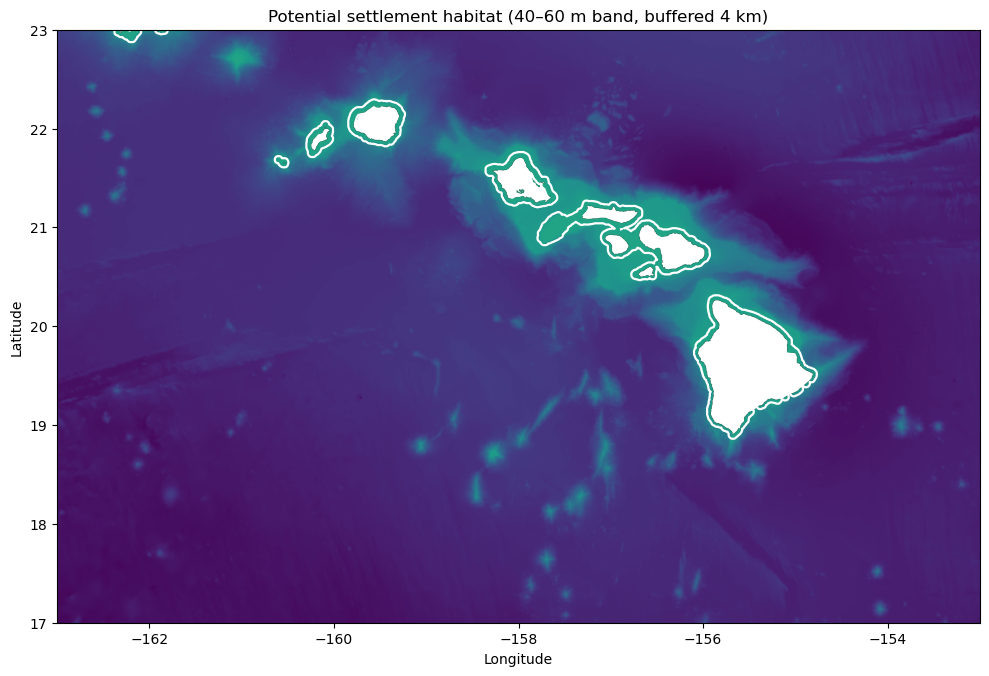

In [48]:
# ============================================================
# FIGURE #1: Bathy + Buffered Habitat Outline
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# GeoTIFF extent in lon/lat
extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# Background bathymetry (unchanged)
plt.imshow(
    tif_data,
    extent=extent,
    origin="upper",
    aspect="equal"
)

# Land overlay as white (depth >= 0)
land_overlay = np.where(tif_data >= 0, 1, np.nan)
plt.imshow(
    land_overlay,
    extent=extent,
    origin="upper",
    aspect="equal",
    cmap="gray",
    vmin=0,
    vmax=1
)

ax = plt.gca()

# Buffered potential habitat outline (40–60 m band + 4 km buffer)
try:
    habitat_poly.boundary.plot(ax=ax, color="white", linewidth=1.6)
except NameError:
    print("NOTE: habitat_poly not found. Run the habitat polygon cell first.")

# Lock to GeoTIFF view
plt.xlim(extent[0], extent[1])
plt.ylim(extent[2], extent[3])

plt.title("Potential settlement habitat (40–60 m band, buffered 4 km)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [49]:
# ===============
# post run stats
# ===============

import xarray as xr
import numpy as np

zarr_path = "Opakapaka_TEST_release1_drift90d.zarr"

# open dataset
ds = xr.open_zarr(zarr_path)

# final timestep index
final_idx = -1

# extract final settled state
final_settled = ds["settled"].isel(obs=final_idx)

# count totals
n_total = final_settled.size
n_settled = int(final_settled.sum().values)
n_unsettled = n_total - n_settled
percent = 100 * n_settled / n_total if n_total > 0 else 0

print("settlement Summary:")
print(f"total particles:      {n_total}")
print(f"settled particles:    {n_settled}")
print(f"unsettled particles:  {n_unsettled}")
print(f"settlement rate:      {percent:.2f}%")
print("settled particles' locations and timestamps are recorded")

settlement Summary:
total particles:      28431
settled particles:    10178
unsettled particles:  18253
settlement rate:      35.80%


In [ ]:
## note from Kyle: I did not touch any of the cells under this one. 

In [ ]:

# - Reads the model’s edges and makes a small “safe box” just inside them.
# - Gently snaps your start points into that box so nothing spawns on the rim.
# - Builds a protective kernel chain (stay in-bounds, stay at surface, move).
# - Runs a 70-day drift and saves positions to a Zarr file.

from datetime import timedelta
import numpy as np
from parcels import ParticleSet, AdvectionRK4


# Why: some Parcels versions put ErrorCode in slightly different places.
# We don’t actually use it here, but this keeps old/new setups calm.
try:
    from parcels.tools.statuscodes import ErrorCode
except Exception:
    try:
        from parcels.statuscodes import ErrorCode
    except Exception:
        class _ErrorCode: ErrorOutOfBounds = 1
        ErrorCode = _ErrorCode()

# --- helper: measure a typical grid step and define a SAFE inner box ---------
# Why: sampling exactly on the outer edge can cause “out of bounds” hiccups.
# We step one full cell inside the model and use that as our safe playground.
def _median_step_2d(a):
    a = np.asarray(a)
    if a.ndim == 2:
        d = np.concatenate([np.abs(np.diff(a,0)).ravel(), np.abs(np.diff(a,1)).ravel()])
    else:
        d = np.abs(np.diff(a).ravel())
    d = d[np.isfinite(d) & (d > 0)]
    return float(np.median(d)) if d.size else 1e-4

def _ensure_constants(fs):
    # model edges
    LON_MIN = float(np.nanmin(fs.U.grid.lon)); LON_MAX = float(np.nanmax(fs.U.grid.lon))
    LAT_MIN = float(np.nanmin(fs.U.grid.lat)); LAT_MAX = float(np.nanmax(fs.U.grid.lat))

    # typical cell sizes
    lon_step = _median_step_2d(fs.U.grid.lon)
    lat_step = _median_step_2d(fs.U.grid.lat)

    # share edges with kernels
    for k, v in (("LON_MIN",LON_MIN),("LON_MAX",LON_MAX),("LAT_MIN",LAT_MIN),("LAT_MAX",LAT_MAX)):
        if not hasattr(fs, k): fs.add_constant(k, v)

    # “safe box” = one full cell inside each side
    SAFE_LON_MIN = LON_MIN + lon_step
    SAFE_LON_MAX = LON_MAX - lon_step
    SAFE_LAT_MIN = LAT_MIN + lat_step
    SAFE_LAT_MAX = LAT_MAX - lat_step
    for k, v in (("SAFE_LON_MIN",SAFE_LON_MIN),("SAFE_LON_MAX",SAFE_LON_MAX),
                 ("SAFE_LAT_MIN",SAFE_LAT_MIN),("SAFE_LAT_MAX",SAFE_LAT_MAX)):
        if not hasattr(fs, k): fs.add_constant(k, float(v))

    # tiny nudges so we never sit exactly on a line
    if not hasattr(fs, "LON_EPS"): fs.add_constant("LON_EPS", float(0.5*lon_step if lon_step>0 else 2e-4))
    if not hasattr(fs, "LAT_EPS"): fs.add_constant("LAT_EPS", float(0.5*lat_step if lat_step>0 else 2e-4))

    # depth limits and the surface level
    z = np.asarray(getattr(fs.U, "depth", fs.U.grid.depth), dtype=float)
    z = z[np.isfinite(z)]
    if z.size == 0: z = np.array([0.0])
    z.sort()
    for k, v in (("DEPTH_MIN",float(z[0])),("DEPTH_MAX",float(z[-1])),("TOP_LEVEL",float(z[0]))):
        if not hasattr(fs, k): fs.add_constant(k, v)

    # how close to shore before we “push off”
    if not hasattr(fs, "shore_threshold"): fs.add_constant("shore_threshold", 0.5)  # in grid cells

_ensure_constants(fieldset)

# --- gently snap the starting points into the SAFE box -----------------------
# Why: guarantees every particle begins in a good spot.
def _pre_clamp_positions(lon_arr, lat_arr, fs):
    lon_arr = np.asarray(lon_arr, dtype=float).copy()
    lat_arr = np.asarray(lat_arr, dtype=float).copy()
    # wrap longitudes if the grid repeats
    span = fs.LON_MAX - fs.LON_MIN
    if span > 0.0:
        lon_arr = ((lon_arr - fs.LON_MIN) % span) + fs.LON_MIN
    # clip to the inner box with a small cushion
    lon_arr = np.clip(lon_arr, fs.SAFE_LON_MIN + fs.LON_EPS, fs.SAFE_LON_MAX - fs.LON_EPS)
    lat_arr = np.clip(lat_arr, fs.SAFE_LAT_MIN + fs.LAT_EPS, fs.SAFE_LAT_MAX - fs.LAT_EPS)
    return lon_arr, lat_arr

if 'release_lons' in globals() and 'release_lats' in globals():
    lon, lat = _pre_clamp_positions(release_lons, release_lats, fieldset)
elif 'lon' in globals() and 'lat' in globals():
    lon, lat = _pre_clamp_positions(lon, lat, fieldset)
else:
    raise NameError("No release positions found. Run the habitat/ocean-mask cell first.")

# --- small safety kernels ----------------------------------------------------
# Why: these act like bumpers in a bowling lane — they keep particles inside.

def clamp_guard(particle, fieldset, time):
    # wrap around if longitudes repeat
    span = fieldset.LON_MAX - fieldset.LON_MIN
    if span > 0.0:
        while particle.lon < fieldset.LON_MIN:  particle.lon += span
        while particle.lon >= fieldset.LON_MAX: particle.lon -= span
    # keep inside the inner box (with tiny cushions)
    if particle.lon <= fieldset.SAFE_LON_MIN: particle.lon = fieldset.SAFE_LON_MIN + fieldset.LON_EPS
    if particle.lon >= fieldset.SAFE_LON_MAX: particle.lon = fieldset.SAFE_LON_MAX - fieldset.LON_EPS
    if particle.lat <= fieldset.SAFE_LAT_MIN: particle.lat = fieldset.SAFE_LAT_MIN + fieldset.LAT_EPS
    if particle.lat >= fieldset.SAFE_LAT_MAX: particle.lat = fieldset.SAFE_LAT_MAX - fieldset.LAT_EPS

def depth_guard(particle, fieldset, time):
    # stay within valid depths
    if particle.depth <= fieldset.DEPTH_MIN: particle.depth = fieldset.DEPTH_MIN
    elif particle.depth >= fieldset.DEPTH_MAX: particle.depth = fieldset.DEPTH_MAX

# stay at the surface for the whole run (no auto-delete cap)
def EggSurface_NoCap(particle, fieldset, time):
    particle.age  += particle.dt
    particle.depth = fieldset.TOP_LEVEL

def DeleteParticle(particle, fieldset, time):
    particle.delete()

# --- make the ParticleSet ----------------------------------------------------
def new_pset():
    # Why: create particles at your chosen points, all starting at the surface.
    return ParticleSet.from_list(
        fieldset=fieldset,
        pclass=DisplacementParticle,   # your custom class with dU/dV etc.
        lon=lon, lat=lat,
        depth=[float(fieldset.TOP_LEVEL)] * len(lon),
        time=None, repeatdt=None
    )

# --- build the movement recipe (kernel chain) --------------------------------
# Order tells the story:
#   keep safe → keep at surface → (re-clamp) → coastal push → ocean currents → keep safe
def build_kernels(pset):
    return (
        pset.Kernel(clamp_guard)
      + pset.Kernel(depth_guard)
      + pset.Kernel(EggSurface_NoCap)   # surface behavior with no lifetime cap
      + pset.Kernel(clamp_guard)
      + pset.Kernel(set_displacement)   # your “push off the shore” choice
      + pset.Kernel(displace)           # apply that push
      + pset.Kernel(AdvectionRK4)       # ROMS currents carry the rest
      + pset.Kernel(depth_guard)
      + pset.Kernel(clamp_guard)
    )

# --- run it ------------------------------------------------------------------
# Small time step = smoother moves and fewer edge issues.
model_dt = timedelta(minutes=2)

pset = new_pset()
kernels = build_kernels(pset)
ofile = pset.ParticleFile(name="Opakapaka_Roms_2015_70d.zarr",
                          outputdt=timedelta(hours=12))  # write twice a day

pset.execute(kernels,
             runtime=timedelta(days=70),   # total drift time
             dt=model_dt,
             output_file=ofile,
             verbose_progress=True)

print("✓ 70-day drift done (saved as Zarr).")



In [ ]:
# --- Keep only ocean points, then (optionally) thin to a target count ---
# Why: stay off land for realism, and cap the total count when runs feel heavy.

import numpy as np, xarray as xr  # tools for arrays and reading grid files

DO_OCEAN_MASK = True    # True = drop releases that fall on land; keeps things realistic
ENABLE_THIN   = True    # True = turn thinning on; False = keep all ocean points
TARGET_N      = 5000    # desired max number of release points when thinning is ON
RNG_SEED      = 42      # seed for random picks so results are repeatable

def _auto_lat_lon_names(da: xr.DataArray):
    """Find the grid's 'lat' and 'lon' coordinate names automatically (grids vary)."""
    names = list(da.coords) if da.coords else list(da.dims)
    lat_name = next(n for n in names if n.lower().startswith(('lat', 'y')))
    lon_name = next(n for n in names if n.lower().startswith(('lon', 'x')))
    return lat_name, lon_name

# --- 1) Ocean mask (drops points whose nearest U-cell is NaN = land) ---
if DO_OCEAN_MASK and (len(release_lons) > 0):
    with xr.open_dataset(roms_files_sorted[0]) as ds0:   # open one ROMS file to check land/sea
        u0 = ds0["u"].isel(time=0, depth=0).load()       # surface U; land cells show up as missing (NaN)
        lat_name, lon_name = _auto_lat_lon_names(u0)     # figure out the grid’s lat/lon names

        # Wrap our lon/lat as xarray arrays so .sel can grab nearest grid cells in one go
        lat_da = xr.DataArray(release_lats, dims="points")
        lon_da = xr.DataArray(release_lons, dims="points")

        # Pull the nearest U values at each release point; NaN means land
        sampled = u0.sel({lat_name: lat_da, lon_name: lon_da}, method="nearest")
        keep_ocean = np.isfinite(sampled.data)           # True = ocean, False = land

    release_lons = np.asarray(release_lons)[keep_ocean]  # keep ocean longitudes
    release_lats = np.asarray(release_lats)[keep_ocean]  # keep ocean latitudes
    print(f"[mask] ocean-only points: {release_lons.size}")
else:
    # still cast to arrays so the thinning step works smoothly
    release_lons = np.asarray(release_lons)
    release_lats = np.asarray(release_lats)

# --- 2) Optional thinning (easy on/off) ---
# Goal: keep runs light by capping the number of points to TARGET_N.
n = release_lons.size
if ENABLE_THIN and (TARGET_N is not None) and n > TARGET_N:
    rng  = np.random.default_rng(RNG_SEED)               # fixed seed → same subset each time
    pick = rng.choice(n, TARGET_N, replace=False)        # choose TARGET_N unique indices
    release_lons = release_lons[pick]
    release_lats = release_lats[pick]
    print(f"[thin] kept {release_lons.size} of {n} (TARGET_N={TARGET_N})")
else:
    print(f"[thin] disabled or not needed (n={n}, TARGET_N={TARGET_N})")

print(f"[ready] releases for spawn day: {release_lons.size}")  # final count going into the run


In [ ]:


# Why: use habitat to place more particles in better areas, and cut count early.  # purpose summary
# What: read lon/lat/prob, weight by habitat, thin randomly, then drop land points.  # process summary
# How: vectorized array ops and one xarray lookup against ROMS grid.  # method summary

# Why slow before: you made millions of points then checked one-by-one.  # prior issue
# Fix: shrink first (KEEP_FRACTION) then do one fast ocean mask

import os, numpy as np, pandas as pd, xarray as xr  # basics: files, arrays, tables, grids
from glob import glob  # to search for the CSV if paths move


# ---- KNOBS you can change ----  # user-tunable settings
MIN_WEIGHT    = 5       # 0..10; skip weak habitat below this level
KEEP_FRACTION = 0.25     # keep this fraction after weighting (1.0 = keep all)
DO_OCEAN_MASK = True     # True = drop land; False = fastest but may include land


# 1) Find your CSV (no header)  # locate release points file (lon, lat, prob)
csv_path = r"C:\Users\woobs\OneDrive\Desktop\Opakapaka_General_Habitat_PB.csv"
print("Using release CSV:", csv_path)


# 2) Read lon/lat/prob (only what we need)  # read three columns as floats
df   = pd.read_csv(csv_path, header=None, usecols=[1, 2, 3], dtype={1:'f4', 2:'f4', 3:'f4'})  # read cols 1,2,3 also the ordering does not matter bc "usecol" changes that 
lon  = df.iloc[:, 0].to_numpy()        # longitudes array
lat  = df.iloc[:, 1].to_numpy()        # latitudes array
prob = df.iloc[:, 2].to_numpy()        # habitat score 0–1


# 3) weight + quick quality filter  # turn prob into repeats; drop weak sites
Weighted_prob = np.rint(prob * 10).astype(int)             # scale 0–1 to 0..10 integers
site_keep     = Weighted_prob >= int(MIN_WEIGHT)           # keep sites at/above the bar
Release_lons  = np.repeat(lon[site_keep], Weighted_prob[site_keep]).astype(float)  # repeat lon by weight
Release_lats  = np.repeat(lat[site_keep], Weighted_prob[site_keep]).astype(float)  # repeat lat by weight
print(f"[step3] after weight/filter: {Release_lons.size:,} points")  # progress info


# 4) THIN FIRST (fast): randomly keep a fraction BEFORE any ocean check  # save time/memory early
if 0 < KEEP_FRACTION < 1 and Release_lons.size > 0:  # only thin when fraction in (0,1) and we have points
    rng    = np.random.default_rng(42)               # fixed seed so it’s repeatable
    n_keep = max(1, int(KEEP_FRACTION * Release_lons.size))  # number to keep
    pick   = rng.choice(Release_lons.size, n_keep, replace=False)  # choose random indices
    Release_lons = Release_lons[pick]  # apply selection to lon
    Release_lats = Release_lats[pick]  # apply selection to lat
print(f"[step4] after thin:           {Release_lons.size:,} points")  # progress info


# 5) Optional ocean-only (vectorized: one call, no Python loop)  # drop land points quickly
# NOTE: roms_files_sorted must already be defined elsewhere (list of ROMS files).  # reminder
if DO_OCEAN_MASK and Release_lons.size > 0:  # only if enabled and we have points
    with xr.open_dataset(roms_files_sorted[0]) as ds0:  # open first ROMS file (enough for land/sea mask)
        U0 = ds0["u"].isel(time=0, depth=0)            # grab a 2D field just to check where ocean exists
        pts_lon = xr.DataArray(Release_lons, dims="points")  # wrap lons as xarray points
        pts_lat = xr.DataArray(Release_lats, dims="points")  # wrap lats as xarray points
        vals = U0.sel(longitude=pts_lon, latitude=pts_lat, method="nearest")  # nearest grid value per point
        keep_ocean = np.isfinite(vals.to_numpy())      # finite = ocean cell, non-finite = land/void

    Release_lons = Release_lons[keep_ocean]  # keep ocean longitudes
    Release_lats = Release_lats[keep_ocean]  # keep ocean latitudes
print(f"[step5] after ocean mask:     {Release_lons.size:,} points")  # progress info


# 6) Hand off to your run cell (1-day spawn, 70-day drift handled there)  # final outputs to use downstream
release_lons = Release_lons  # final longitudes to spawn
release_lats = Release_lats  # final latitudes to spawn
print(  # friendly summary line
    f"[FINAL] one-day spawn particles: {release_lons.size:,}  "
    f"(min_weight={MIN_WEIGHT}, keep_fraction={KEEP_FRACTION:.2f}, ocean_mask={DO_OCEAN_MASK})"
)  # end print


In [ ]:
DT       = int(15 * 60)         # 15 min timestep
OUTPUTDT = int(12 * 60 * 60)     # save every 12 hours


In [ ]:
# --- Keep only ocean points, then (optionally) thin to a target count ---
# Why: stay off land for realism, and cap the total count when runs feel heavy.

import numpy as np, xarray as xr  # tools for arrays and reading grid files

DO_OCEAN_MASK = True    # True = drop releases that fall on land; keeps things realistic
ENABLE_THIN   = True    # True = turn thinning on; False = keep all ocean points
TARGET_N      = 5000    # desired max number of release points when thinning is ON
RNG_SEED      = 42      # seed for random picks so results are repeatable

def _auto_lat_lon_names(da: xr.DataArray):
    """Find the grid's 'lat' and 'lon' coordinate names automatically (grids vary)."""
    names = list(da.coords) if da.coords else list(da.dims)
    lat_name = next(n for n in names if n.lower().startswith(('lat', 'y')))
    lon_name = next(n for n in names if n.lower().startswith(('lon', 'x')))
    return lat_name, lon_name

# --- 1) Ocean mask (drops points whose nearest U-cell is NaN = land) ---
if DO_OCEAN_MASK and (len(release_lons) > 0):
    with xr.open_dataset(roms_files_sorted[0]) as ds0:   # open one ROMS file to check land/sea
        u0 = ds0["u"].isel(time=0, depth=0).load()       # surface U; land cells show up as missing (NaN)
        lat_name, lon_name = _auto_lat_lon_names(u0)     # figure out the grid’s lat/lon names

        # Wrap our lon/lat as xarray arrays so .sel can grab nearest grid cells in one go
        lat_da = xr.DataArray(release_lats, dims="points")
        lon_da = xr.DataArray(release_lons, dims="points")

        # Pull the nearest U values at each release point; NaN means land
        sampled = u0.sel({lat_name: lat_da, lon_name: lon_da}, method="nearest")
        keep_ocean = np.isfinite(sampled.data)           # True = ocean, False = land

    release_lons = np.asarray(release_lons)[keep_ocean]  # keep ocean longitudes
    release_lats = np.asarray(release_lats)[keep_ocean]  # keep ocean latitudes
    print(f"[mask] ocean-only points: {release_lons.size}")
else:
    # still cast to arrays so the thinning step works smoothly
    release_lons = np.asarray(release_lons)
    release_lats = np.asarray(release_lats)

# --- 2) Optional thinning (easy on/off) ---
# Goal: keep runs light by capping the number of points to TARGET_N.
n = release_lons.size
if ENABLE_THIN and (TARGET_N is not None) and n > TARGET_N:
    rng  = np.random.default_rng(RNG_SEED)               # fixed seed → same subset each time
    pick = rng.choice(n, TARGET_N, replace=False)        # choose TARGET_N unique indices
    release_lons = release_lons[pick]
    release_lats = release_lats[pick]
    print(f"[thin] kept {release_lons.size} of {n} (TARGET_N={TARGET_N})")
else:
    print(f"[thin] disabled or not needed (n={n}, TARGET_N={TARGET_N})")

print(f"[ready] releases for spawn day: {release_lons.size}")  # final count going into the run


In [ ]:
# --- Build a 3-D FieldSet from ROMS U/V files (no depth slicing) ---

import xarray as xr
import numpy as np

# 1) Sort files by first time stamp (you already have roms_files_sorted; keep it)
# roms_files_sorted = [...]

grid_file = roms_files_sorted[0]            # use one file to read coords

# 2) Detect the depth coordinate name present in your files
with xr.open_dataset(grid_file, decode_times=True) as ds0:
    # common possibilities in ROMS/levelled datasets
    cand = ["depth", "Depth", "z", "Z", "level", "lev", "s_rho"]
    depth_name = next((c for c in cand if c in ds0.variables or c in ds0.coords), None)
    if depth_name is None:
        raise RuntimeError(
            f"Couldn't find a depth coordinate in {grid_file}. "
            "Open the file and check the name (e.g., 'depth' or 's_rho')."
        )

print("Using depth coordinate:", depth_name)

variables = {"U": "u", "V": "v"}
dimensions = {
    "U": {"lon": "longitude", "lat": "latitude", "time": "time", "depth": depth_name},
    "V": {"lon": "longitude", "lat": "latitude", "time": "time", "depth": depth_name},
}

# For coords, passing the same series of data files works fine when those coords
# live in each file; you can also point lon/lat/depth/time to grid_file.
filenames = {
    "U": {"lon": grid_file, "lat": grid_file, "depth": grid_file, "time": roms_files_sorted, "data": roms_files_sorted},
    "V": {"lon": grid_file, "lat": grid_file, "depth": grid_file, "time": roms_files_sorted, "data": roms_files_sorted},
}

from parcels import FieldSet
fieldset = FieldSet.from_netcdf(
    filenames,
    variables,
    dimensions,
    mesh="spherical",
    allow_time_extrapolation=False,
    interp_method={"U": "freeslip", "V": "freeslip"},
)

# Optional: dateline wrapping
try:
    fieldset.add_periodic_halo(zonal=True)
except Exception:
    pass

# Quick sanity check: make sure we really have vertical levels
zlevs = np.asarray(fieldset.U.depth, dtype=float)
print("Depth levels:", zlevs.shape, f"range=({float(np.nanmin(zlevs)):.2f}, {float(np.nanmax(zlevs)):.2f})")


In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(release_lons, release_lats, s=0.4, alpha=0.25, label="Release (ocean only)")
plt.scatter(pset.lon, pset.lat, s=0.6, alpha=0.9, label="After 70 day")
plt.legend(); plt.title("Opakapaka dispersal — 2 week (2015 ROMS)")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.show()



In [ ]:
# === Bounce/coast fields: seaward displacement & distance-to-shore (Field objects) ===
import numpy as np
import xarray as xr
from parcels import Field, GeographicPolar

# pick a ROMS file on the same grid you used for the FieldSet
grid_file = roms_files_sorted[0]

# --- landmask from surface U (NaNs on land) ---
ds0 = xr.open_dataset(grid_file)
u0  = ds0['u'].isel(time=0, depth=0)   # adjust indices if your dims differ
landmask = np.isnan(u0.values).astype(np.int32)  # land=1, ocean=0

# --- helpers to detect shoreline pixels (4- and 8-neighborhoods) ---
def get_coastal_nodes(mask):
    lap = (np.roll(mask, 1, 0) + np.roll(mask, -1, 0) +
           np.roll(mask, 1, 1) + np.roll(mask, -1, 1) - 4*mask)
    return np.ma.masked_array(mask, lap != 0).mask.astype(np.int32)

def get_coastal_nodes_diagonal(mask):
    lap = (np.roll(mask, 1, 0) + np.roll(mask, -1, 0) +
           np.roll(mask, 1, 1) + np.roll(mask, -1, 1) +
           np.roll(mask, (1,1), (0,1)) + np.roll(mask, (1,-1), (0,1)) +
           np.roll(mask, (-1,1), (0,1)) + np.roll(mask, (-1,-1), (0,1))
           - 8*mask)
    return np.ma.masked_array(mask, lap != 0).mask.astype(np.int32)

def get_shore_nodes(mask):
    lap = (np.roll(mask, 1, 0) + np.roll(mask, -1, 0) +
           np.roll(mask, 1, 1) + np.roll(mask, -1, 1) - 4*mask)
    return np.ma.masked_array(mask, lap == 0).mask.astype(np.int32)

def get_shore_nodes_diagonal(mask):
    lap = (np.roll(mask, 1, 0) + np.roll(mask, -1, 0) +
           np.roll(mask, 1, 1) + np.roll(mask, -1, 1) +
           np.roll(mask, (1,1), (0,1)) + np.roll(mask, (1,-1), (0,1)) +
           np.roll(mask, (-1,1), (0,1)) + np.roll(mask, (-1,-1), (0,1))
           - 8*mask)
    return np.ma.masked_array(mask, lap == 0).mask.astype(np.int32)

# --- distance to nearest shore in (grid-cell) units (simple, local) ---
def distance_to_shore(mask, dx=1.0):
    c  = get_coastal_nodes(mask)
    cd = get_coastal_nodes_diagonal(mask)
    # basic one-ring distance
    dist = (c > 0).astype(np.float32) * dx
    diag = (cd > 0).astype(np.float32) * np.sqrt(2.0*(dx**2))
    dist = np.maximum(dist, diag)
    return dist.astype(np.float32)

# --- unit seaward vector (vx, vy) on the U grid ---
def create_displacement_field(mask):
    shore   = get_shore_nodes(mask)
    shore_c = get_shore_nodes_diagonal(mask) - shore
    Ly = (np.roll(shore, -1, 0) - np.roll(shore, 1, 0)) \
       + (np.roll(shore_c, -1, 0) - np.roll(shore_c, 1, 0))
    Lx = (np.roll(shore, -1, 1) - np.roll(shore, 1, 1)) \
       + (np.roll(shore_c, -1, 1) - np.roll(shore_c, 1, 1))
    vx = -Lx.astype(np.float32); vy = -Ly.astype(np.float32)
    mag = np.sqrt(vx*vx + vy*vy).astype(np.float32); mag[mag == 0] = 1.0
    vx /= mag; vy /= mag
    return vx, vy

vx, vy = create_displacement_field(landmask)
d2s     = distance_to_shore(landmask, dx=1.0)

# --- build Field objects on the U grid and add to fieldset ---
lonU = fieldset.U.grid.lon
latU = fieldset.U.grid.lat

dispfU = Field(name='dispfU', data=vx.astype(np.float32), lon=lonU, lat=latU, mesh='spherical')
dispfV = Field(name='dispfV', data=vy.astype(np.float32), lon=lonU, lat=latU, mesh='spherical')
dist2s = Field(name='distance2shore_fine', data=d2s.astype(np.float32), lon=lonU, lat=latU, mesh='spherical')

fieldset.add_field(dispfU)
fieldset.add_field(dispfV)
fieldset.add_field(dist2s)

# set correct units on the displacement fields
dispfU.units = GeographicPolar()
dispfV.units = GeographicPolar()

# NOTE: removed the old "optional: constant horizontal diffusivity" block here.
# Diffusion is now provided by the Kh_zonal / Kh_meridional FIELDS you added earlier.

# keep your shore threshold as-is
try:
    fieldset.add_constant('shore_threshold', 5.0)
except Exception:
    pass

ds0.close()
print("Bounce fields ready: dispfU, dispfV, distance2shore_fine (units set) + shore_threshold.")


In [ ]:
Weighted_prob = round(df_raw.iloc[:,3]*10)
Release_lats = np.repeat(df_raw.iloc[:,2], Weighted_prob)
Release_lons = np.repeat(df_raw.iloc[:,1], Weighted_prob)
print(Release_lats, Release_lons)
print(lat,lon)


In [ ]:
plt.scatter(Release_lons, Release_lats)


In [ ]:
# === Opakapaka config===
from datetime import datetime
import numpy as np

# Spawning window + cadence + PLD
YEAR            = 2015
RELEASE_START   = datetime(YEAR, 5, 15)   # May 15
RELEASE_END     = datetime(YEAR, 9, 15)   # Sep 15
CADENCE_HOURS   = 24                      # daily releases
PLD_DAYS        = 56                      # 1 d egg + 55 d drift

# Drift depths (not 80 m)
DEPTHS_M        = [20, 30, 40, 50]

# Horizontal diffusion (m^2/s) — mentor wants 5.0
KH = 5.0

# Your Parcels build reads Kh from the fieldset for DiffusionUniformKh (no kwargs),
# so make sure the constants exist:
for name in ("Kh_zonal", "Kh_meridional"):
    try:
        _ = getattr(fieldset, name)
    except Exception:
        try: fieldset.add_constant(name, KH)
        except Exception: pass

print(f"[CONFIG] Spawn window {RELEASE_START:%Y-%m-%d} → {RELEASE_END:%Y-%m-%d} | "
      f"cadence={CADENCE_HOURS} h | PLD={PLD_DAYS} d | depths={DEPTHS_M} | KH={KH} m²/s")


In [ ]:
# === 70-day Parcels run: 14d staggered releases (24h cadence) + 56d (1d egg + 55d drift)
# Variant: fewer cohorts (~340 particles per cohort instead of ~760 total)
from datetime import timedelta, datetime
import os, numpy as np
from parcels import ParticleSet, JITParticle, AdvectionRK4, ParticleFile, DiffusionUniformKh  # <-- added import

# ------- KNOBS -------
CADENCE_HOURS = 24                   # release every 24 h for 14 days
WINDOW_DAYS   = 14
TOTAL_DAYS    = 70                     # 14-day window + 56d (1 egg + 55 drift)
DT_SECONDS    = globals().get('DT', 15*60)            # keep your DT if previously set
OUTPUTDT_SEC  = globals().get('OUTPUTDT', 6*60*60)    # keep your OUTPUTDT if set (e.g., 12h)
START_DEPTH_M = 0.25
SAVE_DIR      = r"C:\ParcelsOut"
RUN_LABEL     = "opakapaka_2015_70d_staggered_uv_inner_fewer"

# --- ---
# Full spawning window + PLD
YEAR = 2015
RELEASE_START = datetime(YEAR, 5, 15)
RELEASE_END   = datetime(YEAR, 9, 15)
PLD_DAYS      = 56
# Allowed drift depths (not 80 m)
DEPTHS_M      = [20, 30, 40, 50]
# Diffusion strength
KH = 5.0
# Ensure DiffusionUniformKh can read Kh_* from fieldset on this Parcels version
try: _ = fieldset.Kh_zonal
except Exception:
    try: fieldset.add_constant('Kh_zonal', KH)
    except Exception: pass
try: _ = fieldset.Kh_meridional
except Exception:
    try: fieldset.add_constant('Kh_meridional', KH)
    except Exception: pass
# --- end mentor settings ---

# ------- REQUIREMENTS -------
try:
    fieldset
    release_lons; release_lats
except NameError as e:
    raise RuntimeError("Run your FieldSet + releases cells first.") from e

# ------- Get U/V grid bounds and build an 'inner' safe box (~half a cell inset) -------
u_g = fieldset.U.grid; v_g = fieldset.V.grid
def _cell_margin(grid):
    lon = np.asarray(grid.lon).astype(float).ravel()
    lat = np.asarray(grid.lat).astype(float).ravel()
    dlon = np.nanmin(np.abs(np.diff(np.unique(lon)))) if lon.size > 1 else 0.05
    dlat = np.nanmin(np.abs(np.diff(np.unique(lat)))) if lat.size > 1 else 0.05
    if not np.isfinite(dlon): dlon = 0.05
    if not np.isfinite(dlat): dlat = 0.05
    return max(dlon, dlat)

margin = max(_cell_margin(u_g), _cell_margin(v_g)) * 0.51  # ~half a cell

u_lon_min, u_lon_max = float(np.nanmin(u_g.lon)), float(np.nanmax(u_g.lon))
u_lat_min, u_lat_max = float(np.nanmin(u_g.lat)), float(np.nanmax(u_g.lat))
v_lon_min, v_lon_max = float(np.nanmin(v_g.lon)), float(np.nanmax(v_g.lon))
v_lat_min, v_lat_max = float(np.nanmin(v_g.lat)), float(np.nanmax(v_g.lat))

LON_MIN = max(u_lon_min, v_lon_min); LON_MAX = min(u_lon_max, v_lon_max)
LAT_MIN = max(u_lat_min, v_lat_min); LAT_MAX = min(v_lat_max, v_lat_max)  # (left as in your code)
if not (LON_MIN < LON_MAX and LAT_MIN < LAT_MAX):
    raise RuntimeError("U/V grid intersection is empty — check ROMS inputs.")

# Inner box to keep RK4 substeps inside the grid
LON_MIN_INNER = LON_MIN + margin; LON_MAX_INNER = LON_MAX - margin
LAT_MIN_INNER = LAT_MIN + margin; LAT_MAX_INNER = LAT_MAX - margin
for n, v in [("LON_MIN_INNER", LON_MIN_INNER), ("LON_MAX_INNER", LON_MAX_INNER),
             ("LAT_MIN_INNER", LAT_MIN_INNER), ("LAT_MAX_INNER", LAT_MAX_INNER)]:
    try: fieldset.add_constant(n, v)
    except Exception: pass

# ------- Filter + clip releases into INNER domain -------
rlon = np.asarray(release_lons, dtype=np.float64)
rlat = np.asarray(release_lats, dtype=np.float64)
inside = (rlon >= LON_MIN_INNER) & (rlon <= LON_MAX_INNER) & (rlat >= LAT_MIN_INNER) & (rlat <= LAT_MAX_INNER)
if not np.all(inside):
    rlon = rlon[inside]; rlat = rlat[inside]
    print(f"⚠️ filtered releases to inner U/V domain: {rlon.size} particles remain")
rlon = np.clip(rlon, LON_MIN_INNER, LON_MAX_INNER)
rlat = np.clip(rlat, LAT_MIN_INNER, LAT_MAX_INNER)

# ------- Build staggered cohorts with fewer particles -------
ncohorts = int(((WINDOW_DAYS * 24) // CADENCE_HOURS) * 0.5)   # cut in half
cohort_times = (np.arange(ncohorts, dtype=np.int64) * (CADENCE_HOURS * 3600))

# --- (NEW) override: use the entire spawn window May 15 → Sep 15 (daily) ---
secs_per_cohort = CADENCE_HOURS * 3600
ncohorts = int((RELEASE_END - RELEASE_START).total_seconds() // secs_per_cohort) + 1
cohort_times = (np.arange(ncohorts, dtype=np.int64) * secs_per_cohort)
# --- end override ---

lon_all  = np.tile(rlon, ncohorts)
lat_all  = np.tile(rlat, ncohorts)
time_all = np.repeat(cohort_times, rlon.size)
depth_all = np.full(lon_all.shape, START_DEPTH_M, dtype=np.float32)

# --- (NEW) override: set depths to one of [20, 30, 40, 50] m ---
_rng = np.random.default_rng(7)
depth_all = _rng.choice(np.asarray(DEPTHS_M, dtype=np.float32), size=lon_all.size).astype(np.float32)
# --- end override ---

# ------- Fresh ParticleSet -------
if "pset" in globals():
    del pset
pset = ParticleSet(fieldset=fieldset, pclass=JITParticle,
                   lon=lon_all, lat=lat_all, depth=depth_all, time=time_all)

# ------- Clip each step + advection (NO shorebreak/bounce) -------
def PreClip(particle, fieldset, time):
    if particle.lon < fieldset.LON_MIN_INNER: particle.lon = fieldset.LON_MIN_INNER
    if particle.lon > fieldset.LON_MAX_INNER: particle.lon = fieldset.LON_MAX_INNER
    if particle.lat < fieldset.LAT_MIN_INNER: particle.lat = fieldset.LAT_MIN_INNER
    if particle.lat > fieldset.LAT_MAX_INNER: particle.lat = fieldset.LAT_MAX_INNER

def PostClip(particle, fieldset, time):
    if particle.lon < fieldset.LON_MIN_INNER: particle.lon = fieldset.LON_MIN_INNER
    if particle.lon > fieldset.LON_MAX_INNER: particle.lon = fieldset.LON_MAX_INNER
    if particle.lat < fieldset.LAT_MIN_INNER: particle.lat = fieldset.LAT_MIN_INNER
    if particle.lat > fieldset.LAT_MAX_INNER: particle.lat = fieldset.LAT_MAX_INNER

kernels = pset.Kernel(PreClip) + AdvectionRK4 + pset.Kernel(PostClip)

# --- (NEW) add diffusion KH = 5.0 m^2/s (reads Kh_* from fieldset) ---
kernels = kernels + DiffusionUniformKh
# --- end addition ---

# ------- ParticleFile (supports multiple ctor signatures) -------
os.makedirs(SAVE_DIR, exist_ok=True)
run_tag   = datetime.now().strftime("%Y%m%d_%H%M%S")
zarr_path = os.path.join(SAVE_DIR, f"{RUN_LABEL}_{run_tag}.zarr")
def make_particlefile(pset, path, outputdt_seconds):
    odt = timedelta(seconds=outputdt_seconds)
    try:    return ParticleFile(name=path, outputdt=odt, particleset=pset)  # newer
    except TypeError:
        try: return ParticleFile(pset, name=path, outputdt=odt)             # alt
        except TypeError:
            return ParticleFile(pset, path, odt)                            # older
pfile = make_particlefile(pset, zarr_path, OUTPUTDT_SEC)

# --- (NEW) override: runtime = full window + PLD (keep your execute call unchanged) ---
TOTAL_DAYS = ((RELEASE_END - RELEASE_START) + timedelta(days=PLD_DAYS)).days
# --- end override ---

# ------- Execute (no recovery kwargs; inner-bounds prevent OOB) -------
print(f"Particles per cohort: {rlon.size} | Cohorts: {ncohorts} | Total particles: {len(lon_all)}")
print(f"U/V inner domain: lon[{LON_MIN_INNER:.3f},{LON_MAX_INNER:.3f}]  lat[{LAT_MIN_INNER:.3f},{LAT_MAX_INNER:.3f}]")
print(f"Runtime: {TOTAL_DAYS} days | Save every {OUTPUTDT_SEC/3600:.0f} h")
print("Output:", zarr_path)

# --- Spawn-window status prints (no in-run logger needed) ---
first_release_dt = RELEASE_START
last_release_dt  = RELEASE_START + timedelta(seconds=int(time_all.max()))
end_spawn_dt     = RELEASE_END
drift_end_dt     = RELEASE_END + timedelta(days=PLD_DAYS)

print(f"[SPAWN] First release scheduled: {first_release_dt:%Y-%m-%d} 00:00")
print(f"[SPAWN] Last  release scheduled: {last_release_dt:%Y-%m-%d} 00:00")
print(f"[SPAWN] Spawn window ends:       {end_spawn_dt:%Y-%m-%d}")
print(f"[SPAWN] Drift continues {PLD_DAYS} d → simulation ends: {drift_end_dt:%Y-%m-%d}")

pset.execute(
    kernels,
    runtime=timedelta(days=TOTAL_DAYS),
    dt=timedelta(seconds=DT_SECONDS),
    output_file=pfile
)

print("Done. Saved:", zarr_path)


In [ ]:
import numpy as np
u_g = fieldset.U.grid; v_g = fieldset.V.grid
print("U lon:", float(np.nanmin(u_g.lon)), float(np.nanmax(u_g.lon)), "lat:", float(np.nanmin(u_g.lat)), float(np.nanmax(u_g.lat)))
print("V lon:", float(np.nanmin(v_g.lon)), float(np.nanmax(v_g.lon)), "lat:", float(np.nanmin(v_g.lat)), float(np.nanmax(v_g.lat)))
print("releases lon:", float(np.min(release_lons)), float(np.max(release_lons)),
      "lat:", float(np.min(release_lats)), float(np.max(release_lats)))


In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(release_lons, release_lats, s=0.4, alpha=0.25, label="Release (ocean only)")
plt.scatter(pset.lon, pset.lat, s=0.6, alpha=0.9, label="After 70 day")
plt.legend(); plt.title("Opakapaka dispersal — 2 week (2015 ROMS)")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.show()


In [ ]:
# === 70-day Parcels run: 14d staggered releases (24h cadence) + 56d (1d egg + 55d drift)
# Variant: fewer cohorts (~340 particles per cohort instead of ~760 total)
from datetime import timedelta, datetime
import os, numpy as np
from parcels import ParticleSet, JITParticle, AdvectionRK4, ParticleFile

# ------- KNOBS -------
CADENCE_HOURS = 24                   # release every 24 h for 14 days
WINDOW_DAYS   = 14
TOTAL_DAYS    = 70                     # 14-day window + 56d (1 egg + 55 drift)
DT_SECONDS    = globals().get('DT', 15*60)            # keep your DT if previously set
OUTPUTDT_SEC  = globals().get('OUTPUTDT', 6*60*60)    # keep your OUTPUTDT if set (e.g., 12h)
START_DEPTH_M = 0.25
SAVE_DIR      = r"C:\ParcelsOut"
RUN_LABEL     = "opakapaka_2015_70d_staggered_uv_inner_fewer"

# ------- REQUIREMENTS -------
try:
    fieldset
    release_lons; release_lats
except NameError as e:
    raise RuntimeError("Run your FieldSet + releases cells first.") from e

# ------- Get U/V grid bounds and build an 'inner' safe box (~half a cell inset) -------
u_g = fieldset.U.grid; v_g = fieldset.V.grid
def _cell_margin(grid):
    lon = np.asarray(grid.lon).astype(float).ravel()
    lat = np.asarray(grid.lat).astype(float).ravel()
    dlon = np.nanmin(np.abs(np.diff(np.unique(lon)))) if lon.size > 1 else 0.05
    dlat = np.nanmin(np.abs(np.diff(np.unique(lat)))) if lat.size > 1 else 0.05
    if not np.isfinite(dlon): dlon = 0.05
    if not np.isfinite(dlat): dlat = 0.05
    return max(dlon, dlat)

margin = max(_cell_margin(u_g), _cell_margin(v_g)) * 0.51  # ~half a cell

u_lon_min, u_lon_max = float(np.nanmin(u_g.lon)), float(np.nanmax(u_g.lon))
u_lat_min, u_lat_max = float(np.nanmin(u_g.lat)), float(np.nanmax(u_g.lat))
v_lon_min, v_lon_max = float(np.nanmin(v_g.lon)), float(np.nanmax(v_g.lon))
v_lat_min, v_lat_max = float(np.nanmin(v_g.lat)), float(np.nanmax(v_g.lat))

LON_MIN = max(u_lon_min, v_lon_min); LON_MAX = min(u_lon_max, v_lon_max)
LAT_MIN = max(u_lat_min, v_lat_min); LAT_MAX = min(v_lat_max, v_lat_max)
if not (LON_MIN < LON_MAX and LAT_MIN < LAT_MAX):
    raise RuntimeError("U/V grid intersection is empty — check ROMS inputs.")

# Inner box to keep RK4 substeps inside the grid
LON_MIN_INNER = LON_MIN + margin; LON_MAX_INNER = LON_MAX - margin
LAT_MIN_INNER = LAT_MIN + margin; LAT_MAX_INNER = LAT_MAX - margin
for n, v in [("LON_MIN_INNER", LON_MIN_INNER), ("LON_MAX_INNER", LON_MAX_INNER),
             ("LAT_MIN_INNER", LAT_MIN_INNER), ("LAT_MAX_INNER", LAT_MAX_INNER)]:
    try: fieldset.add_constant(n, v)
    except Exception: pass

# ------- Filter + clip releases into INNER domain -------
rlon = np.asarray(release_lons, dtype=np.float64)
rlat = np.asarray(release_lats, dtype=np.float64)
inside = (rlon >= LON_MIN_INNER) & (rlon <= LON_MAX_INNER) & (rlat >= LAT_MIN_INNER) & (rlat <= LAT_MAX_INNER)
if not np.all(inside):
    rlon = rlon[inside]; rlat = rlat[inside]
    print(f"⚠️ filtered releases to inner U/V domain: {rlon.size} particles remain")
rlon = np.clip(rlon, LON_MIN_INNER, LON_MAX_INNER)
rlat = np.clip(rlat, LAT_MIN_INNER, LAT_MAX_INNER)

# ------- Build staggered cohorts with fewer particles -------
ncohorts = int(((WINDOW_DAYS * 24) // CADENCE_HOURS) * 0.5)   # cut in half
cohort_times = (np.arange(ncohorts, dtype=np.int64) * (CADENCE_HOURS * 3600))

lon_all  = np.tile(rlon, ncohorts)
lat_all  = np.tile(rlat, ncohorts)
time_all = np.repeat(cohort_times, rlon.size)
depth_all = np.full(lon_all.shape, START_DEPTH_M, dtype=np.float32)

# ------- Fresh ParticleSet -------
if "pset" in globals():
    del pset
pset = ParticleSet(fieldset=fieldset, pclass=JITParticle,
                   lon=lon_all, lat=lat_all, depth=depth_all, time=time_all)

# ------- Clip each step + advection (NO shorebreak/bounce) -------
def PreClip(particle, fieldset, time):
    if particle.lon < fieldset.LON_MIN_INNER: particle.lon = fieldset.LON_MIN_INNER
    if particle.lon > fieldset.LON_MAX_INNER: particle.lon = fieldset.LON_MAX_INNER
    if particle.lat < fieldset.LAT_MIN_INNER: particle.lat = fieldset.LAT_MIN_INNER
    if particle.lat > fieldset.LAT_MAX_INNER: particle.lat = fieldset.LAT_MAX_INNER

def PostClip(particle, fieldset, time):
    if particle.lon < fieldset.LON_MIN_INNER: particle.lon = fieldset.LON_MIN_INNER
    if particle.lon > fieldset.LON_MAX_INNER: particle.lon = fieldset.LON_MAX_INNER
    if particle.lat < fieldset.LAT_MIN_INNER: particle.lat = fieldset.LAT_MIN_INNER
    if particle.lat > fieldset.LAT_MAX_INNER: particle.lat = fieldset.LAT_MAX_INNER

kernels = pset.Kernel(PreClip) + AdvectionRK4 + pset.Kernel(PostClip)

# ------- ParticleFile (supports multiple ctor signatures) -------
os.makedirs(SAVE_DIR, exist_ok=True)
run_tag   = datetime.now().strftime("%Y%m%d_%H%M%S")
zarr_path = os.path.join(SAVE_DIR, f"{RUN_LABEL}_{run_tag}.zarr")
def make_particlefile(pset, path, outputdt_seconds):
    odt = timedelta(seconds=outputdt_seconds)
    try:    return ParticleFile(name=path, outputdt=odt, particleset=pset)  # newer
    except TypeError:
        try: return ParticleFile(pset, name=path, outputdt=odt)             # alt
        except TypeError:
            return ParticleFile(pset, path, odt)                            # older
pfile = make_particlefile(pset, zarr_path, OUTPUTDT_SEC)

# ------- Execute (no recovery kwargs; inner-bounds prevent OOB) -------
print(f"Particles per cohort: {rlon.size} | Cohorts: {ncohorts} | Total particles: {len(lon_all)}")
print(f"U/V inner domain: lon[{LON_MIN_INNER:.3f},{LON_MAX_INNER:.3f}]  lat[{LAT_MIN_INNER:.3f},{LAT_MAX_INNER:.3f}]")
print(f"Runtime: {TOTAL_DAYS} days | Save every {OUTPUTDT_SEC/3600:.0f} h")
print("Output:", zarr_path)

pset.execute(kernels,
    runtime=timedelta(days=TOTAL_DAYS),
    dt=timedelta(seconds=DT_SECONDS),
    output_file=pfile
)

print("Done. Saved:", zarr_path)


In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(release_lons, release_lats, s=0.4, alpha=0.25, label="Release (ocean only)")
plt.scatter(pset.lon, pset.lat, s=0.6, alpha=0.9, label="After 70 day")
plt.legend(); plt.title("Opakapaka dispersal — 2 week (2015 ROMS)")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.show()


In [ ]:
# === 2-week spawning window (14d) + 56d drift — fewer cohorts variant (JIT-safe clamps) ===
from datetime import timedelta, datetime
import os, numpy as np
from parcels import ParticleSet, JITParticle, AdvectionRK4, ParticleFile, DiffusionUniformKh

# ------- KNOBS (same as your original shape) -------
CADENCE_HOURS = 24            # release every 24 h
WINDOW_DAYS   = 14            # 2-week spawn window
TOTAL_DAYS    = 70            # 14d window + 56d (1 egg + 55 drift)
DT_SECONDS    = globals().get('DT',       15*60)
OUTPUTDT_SEC  = globals().get('OUTPUTDT', 12*60*60)
START_DEPTH_M = 0.25
SAVE_DIR      = r"C:\ParcelsOut"
RUN_LABEL     = "opakapaka_2015_70d_staggered_uv_inner_fewer"

# ---- Mentor adds ----
YEAR          = 2015
RELEASE_START = datetime(YEAR, 5, 15)   # start of 2-week window
PLD_DAYS      = 56
DEPTHS_M      = [20, 30, 40, 50]        # not 80 m
KH            = 5.0                     # m^2/s diffusion

# DiffusionUniformKh on this Parcels build reads KH from fieldset constants:
for name in ("Kh_zonal", "Kh_meridional"):
    try:
        _ = getattr(fieldset, name)
    except Exception:
        try: fieldset.add_constant(name, float(KH))
        except Exception: pass

# ------- REQUIREMENTS -------
try:
    fieldset
    release_lons; release_lats
except NameError as e:
    raise RuntimeError("Run your FieldSet + releases cells first.") from e

# ------- Inner 'safe box' from U/V overlap -------
u_g = fieldset.U.grid; v_g = fieldset.V.grid
def _cell_margin(grid):
    lon = np.asarray(grid.lon).astype(float).ravel()
    lat = np.asarray(grid.lat).astype(float).ravel()
    dlon = np.nanmin(np.abs(np.diff(np.unique(lon)))) if lon.size > 1 else 0.05
    dlat = np.nanmin(np.abs(np.diff(np.unique(lat)))) if lat.size > 1 else 0.05
    if not np.isfinite(dlon): dlon = 0.05
    if not np.isfinite(dlat): dlat = 0.05
    return max(dlon, dlat)

margin = max(_cell_margin(u_g), _cell_margin(v_g)) * 0.51
u_lon_min, u_lon_max = float(np.nanmin(u_g.lon)), float(np.nanmax(u_g.lon))
u_lat_min, u_lat_max = float(np.nanmin(u_g.lat)), float(np.nanmax(u_g.lat))
v_lon_min, v_lon_max = float(np.nanmin(v_g.lon)), float(np.nanmax(v_g.lon))
v_lat_min, v_lat_max = float(np.nanmin(v_g.lat)), float(np.nanmax(v_g.lat))
LON_MIN = max(u_lon_min, v_lon_min); LON_MAX = min(u_lon_max, v_lon_max)
LAT_MIN = max(u_lat_min, v_lat_min); LAT_MAX = min(v_lat_max, v_lat_max)
if not (LON_MIN < LON_MAX and LAT_MIN < LAT_MAX):
    raise RuntimeError("U/V grid intersection is empty — check ROMS inputs.")

LON_MIN_INNER = LON_MIN + margin; LON_MAX_INNER = LON_MAX - margin
LAT_MIN_INNER = LAT_MIN + margin; LAT_MAX_INNER = LAT_MAX - margin
for n, v in [("LON_MIN_INNER", LON_MIN_INNER), ("LON_MAX_INNER", LON_MAX_INNER),
             ("LAT_MIN_INNER", LAT_MIN_INNER), ("LAT_MAX_INNER", LAT_MAX_INNER)]:
    try: fieldset.add_constant(n, v)
    except Exception: pass

# ------- Filter + clip releases into INNER domain -------
rlon = np.asarray(release_lons, dtype=np.float64)
rlat = np.asarray(release_lats, dtype=np.float64)
inside = ((rlon >= LON_MIN_INNER) & (rlon <= LON_MAX_INNER) &
          (rlat >= LAT_MIN_INNER) & (rlat <= LAT_MAX_INNER))
if not np.all(inside):
    rlon = rlon[inside]; rlat = rlat[inside]
    print(f"⚠️ filtered releases to inner U/V domain: {rlon.size} particles remain")
rlon = np.clip(rlon, LON_MIN_INNER, LON_MAX_INNER)
rlat = np.clip(rlat, LAT_MIN_INNER, LAT_MAX_INNER)

# ------- Build 2-week staggered cohorts (FEWER = 0.5×) -------
FEWER = True
base_cohorts = (WINDOW_DAYS * 24) // CADENCE_HOURS  # 14 if daily
ncohorts = int(base_cohorts * (0.5 if FEWER else 1.0))  # -> 7 when FEWER=True
cohort_times = (np.arange(ncohorts, dtype=np.int64) * (CADENCE_HOURS * 3600))  # seconds after RELEASE_START

lon_all   = np.tile(rlon, ncohorts)
lat_all   = np.tile(rlat, ncohorts)
time_all  = np.repeat(cohort_times, rlon.size)
_rng = np.random.default_rng(7)
depth_all = _rng.choice(np.asarray(DEPTHS_M, dtype=np.float32), size=lon_all.size).astype(np.float32)

# ------- ParticleSet -------
if "pset" in globals(): del pset
pset = ParticleSet(fieldset=fieldset, pclass=JITParticle,
                   lon=lon_all, lat=lat_all, depth=depth_all, time=time_all)

# ------- JIT-safe clamp kernels + advection + diffusion -------
def PreClip(particle, fieldset, time):
    if particle.lon < fieldset.LON_MIN_INNER: particle.lon = fieldset.LON_MIN_INNER
    if particle.lon > fieldset.LON_MAX_INNER: particle.lon = fieldset.LON_MAX_INNER
    if particle.lat < fieldset.LAT_MIN_INNER: particle.lat = fieldset.LAT_MIN_INNER
    if particle.lat > fieldset.LAT_MAX_INNER: particle.lat = fieldset.LAT_MAX_INNER

def PostClip(particle, fieldset, time):
    if particle.lon < fieldset.LON_MIN_INNER: particle.lon = fieldset.LON_MIN_INNER
    if particle.lon > fieldset.LON_MAX_INNER: particle.lon = fieldset.LON_MAX_INNER
    if particle.lat < fieldset.LAT_MIN_INNER: particle.lat = fieldset.LAT_MIN_INNER
    if particle.lat > fieldset.LAT_MAX_INNER: particle.lat = fieldset.LAT_MAX_INNER

kernels = pset.Kernel(PreClip) + AdvectionRK4 + DiffusionUniformKh + pset.Kernel(PostClip)

# ------- Output -------
os.makedirs(SAVE_DIR, exist_ok=True)
run_tag  = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = os.path.join(SAVE_DIR, f"{RUN_LABEL}_{run_tag}.zarr")
def make_particlefile(pset, path, outputdt_seconds):
    odt = timedelta(seconds=outputdt_seconds)
    try:    return ParticleFile(name=path, outputdt=odt, particleset=pset)
    except TypeError:
        try: return ParticleFile(pset, name=path, outputdt=odt)
        except TypeError:
            return ParticleFile(pset, path, odt)
pfile = make_particlefile(pset, out_path, OUTPUTDT_SEC)

# ------- Prints -------
print(f"Particles per cohort: {rlon.size} | Cohorts: {ncohorts} | Total particles: {len(lon_all)}")
print(f"U/V inner domain: lon[{LON_MIN_INNER:.3f},{LON_MAX_INNER:.3f}]  lat[{LAT_MIN_INNER:.3f},{LAT_MAX_INNER:.3f}]")
print(f"Runtime: {TOTAL_DAYS} days | Save every {OUTPUTDT_SEC/3600:.0f} h")
print("Output:", out_path)

first_release_dt = RELEASE_START
last_release_dt  = RELEASE_START + timedelta(seconds=int(time_all.max()))
print(f"[SPAWN] First release scheduled: {first_release_dt:%Y-%m-%d} 00:00")
print(f"[SPAWN] Last  release scheduled: {last_release_dt:%Y-%m-%d} 00:00")
print(f"[SPAWN] Drift continues {PLD_DAYS} d; total runtime = {TOTAL_DAYS} days")

# ------- Execute (70-day sim) -------
pset.execute(
    kernels,
    runtime=timedelta(days=TOTAL_DAYS),
    dt=timedelta(seconds=DT_SECONDS),
    output_file=pfile
)

print("Done. Saved:", out_path)


In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(release_lons, release_lats, s=0.4, alpha=0.25, label="Release (ocean only)")
plt.scatter(pset.lon, pset.lat, s=0.6, alpha=0.9, label="After 70 day")
plt.legend(); plt.title("Opakapaka dispersal — 2 week (2015 ROMS)")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.show()
